# Part 1: Introduction

## 1.1 Background
Online platforms such as Steam host millions of user reviews, making it difficult for players to quickly identify helpful feedback. Although community voting highlights useful reviews, many valuable comments remain unnoticed due to limited exposure and delayed voting.

## 1.2 Objective
This project addresses this challenge by predicting the number of helpful votes (votes_up) to estimate review helpfulness. We use review text, temporal factors such as the time gap between game release and review posting, reviewer activity attributes, and game-level metadata to model the signals that influence usefulness. By capturing these factors, the system can support improved review ranking and highlight high-quality content, enhancing user decision-making and platform usability.

  

## 1.3 Contribution

# Part 2: Dataset Description

## 2.1 Dataset 1: Steam Reviews 2020

*   Source: https://www.kaggle.com/datasets/najzeko/steam-reviews-2020
*   Dataset size: 4,374,931 reviews (22 columns).
*   Overview: This dataset contains review text, timestamps, recommendation status, and community feedback metrics (e.g., votes_up, votes_funny). It also includes reviewer activity indicators. It provides primary signals for modeling review helpfulness.

## 2.2 Dataset 2: Steam Games Dataset

*   Source: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset/data
*   Dataset size: 89,618 games (47 columns).
*   Overview: This dataset provides game-level metadata such as release date, genre, price, and popularity indicators, enabling temporal and contextual feature engineering.

## 2.3 Data Integration

The two datasets are merged using game identifiers (appid) to enrich review-level data with game-level attributes.

## 2.4 Dataset Column Descriptions

**2.4.1 Reviews Dataset Column Descriptions**

- Unnamed: 0 – index column generated during data export  
- appid – unique identifier of the game  
- recommendationid – unique identifier of the recommendation  
- language – language used by the reviewer  
- review – text of the written review  

- timestamp_created – Unix timestamp when the review was created  
- timestamp_updated – Unix timestamp when the review was last updated  

- voted_up – indicates whether the review is positive (true) or negative (false)  
- votes_up – number of users who found the review helpful  
- votes_funny – number of users who found the review funny  
- weighted_vote_score – overall helpfulness score of the review  
- comment_count – number of comments on the review  

- steam_purchase – whether the reviewer purchased the game on Steam  
- received_for_free – whether the reviewer received the game for free  
- written_during_early_access – whether the review was written during early access  

- steamid – unique identifier of the user  
- num_games_owned – number of games owned by the user  
- num_reviews – number of reviews written by the user  

- playtime_forever – total playtime of the game  
- playtime_last_two_weeks – playtime in the last two weeks  
- playtime_at_review – playtime when the review was written  
- last_played – timestamp of the user’s last gameplay session  

**2.4.2 Games Dataset Column Descriptions**

- appid – unique identifier of the game  
- name – name of the game  
- release_date – release date of the game  
- required_age – minimum required age to play  
- price – price of the game  
- dlc_count – number of downloadable content (DLCs)  
- detailed_description – full description of the game  
- about_the_game – short description of the game  
- short_description – brief summary of the game  
- reviews – user review summary text  
- header_image – URL of the game’s header image  
- website – official website of the game  
- support_url – support website URL  
- support_email – support contact email  

- windows – whether the game supports Windows  
- mac – whether the game supports macOS  
- linux – whether the game supports Linux  

- metacritic_score – Metacritic score of the game  
- metacritic_url – URL to the Metacritic page  

- achievements – number of achievements in the game  
- recommendations – number of user recommendations  
- notes – additional notes about the game  

- supported_languages – languages supported by the game  
- full_audio_languages – languages with full audio support  

- packages – available purchase packages  
- developers – game developers  
- publishers – game publishers  
- categories – game categories (e.g., single-player, multiplayer)  
- genres – game genres (e.g., action, RPG)  
- screenshots – list of screenshot URLs  
- movies – list of video URLs  

- user_score – user rating score  
- score_rank – ranking based on score  

- positive – number of positive ratings  
- negative – number of negative ratings  
- estimated_owners – estimated number of owners  

- average_playtime_forever – average total playtime  
- average_playtime_2weeks – average playtime in the last two weeks  
- median_playtime_forever – median total playtime  
- median_playtime_2weeks – median playtime in the last two weeks  

- discount – discount percentage  
- peak_ccu – peak concurrent users  

- tags – tags describing the game  

- pct_pos_total – percentage of positive reviews (overall)  
- num_reviews_total – total number of reviews  
- pct_pos_recent – percentage of positive recent reviews  
- num_reviews_recent – number of recent reviews  


# Part 3: Problem Formulation

Challenges

    Heavy-tailed distribution

    Missing values

    Multilingual text

    Class imbalance (many low-vote reviews)


# Part 4: Data Preprocessing

## 4.1  Technical Preliminaries

In [1]:
# Install dependencies if running locally (Colab already has these)
import importlib, subprocess, sys

_required = [
    "pandas", "numpy", "scikit-learn", "matplotlib",
    "seaborn", "lightgbm", "xgboost", "scipy", "jinja2"
]

for _pkg in _required:
    _import_name = "sklearn" if _pkg == "scikit-learn" else _pkg.replace("-", "_")
    if importlib.util.find_spec(_import_name) is None:
        print(f"Installing {_pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg, "-q"])

print("All dependencies ready.")

All dependencies ready.


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [3]:
# ⚠️ COLAB ONLY — Skip when running locally
# In Colab, this mounts Google Drive so files can be read from /content/drive/MyDrive/
# Locally, drive mounting is not needed; data files are read from the local directory instead.

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUNNING_IN_COLAB = True
except ModuleNotFoundError:
    RUNNING_IN_COLAB = False
    print("Not running in Colab — skipping Drive mount.")

Not running in Colab — skipping Drive mount.


## 4.2 Data Loading

In [4]:
import os

# PATH DIFFERS BETWEEN COLAB AND LOCAL
# - Colab:  files live in Google Drive → /content/drive/MyDrive/
# - Local:  files live in the project folder on your machine
if RUNNING_IN_COLAB:
    REVIEWS_PATH = "/content/drive/MyDrive/big_reviews.csv"
    GAMES_PATH   = "/content/drive/MyDrive/games_march2025_cleaned.csv"
else:
    # LOCAL FIX: os.getcwd() is used instead of __file__
    # because __file__ is not reliable inside Jupyter notebooks.
    _BASE = os.getcwd()
    REVIEWS_PATH = os.path.join(_BASE, "big_reviews.csv")
    GAMES_PATH   = os.path.join(_BASE, "games_march2025_cleaned.csv")

print(f"Running in {'Colab' if RUNNING_IN_COLAB else 'Local Machine'}")
print(f"REVIEWS_PATH : {REVIEWS_PATH}")
print(f"GAMES_PATH   : {GAMES_PATH}")

# Load datasets
reviews = pd.read_csv(REVIEWS_PATH)
games   = pd.read_csv(GAMES_PATH)

# Basic information of datasets
print("\nReviews Dataset shape:", reviews.shape)
print("Games Dataset shape:",   games.shape)

print("\nReviews Dataset columns and types:")
print(reviews.info())

print("\nGames Dataset columns and types:")
print(games.info())

Running in Local Machine
REVIEWS_PATH : d:\Github_Desktop_File\ECE-9612-Group-Project\big_reviews.csv
GAMES_PATH   : d:\Github_Desktop_File\ECE-9612-Group-Project\games_march2025_cleaned.csv

Reviews Dataset shape: (4374931, 22)
Games Dataset shape: (89618, 47)

Reviews Dataset columns and types:
<class 'pandas.DataFrame'>
RangeIndex: 4374931 entries, 0 to 4374930
Data columns (total 22 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Unnamed: 0                   int64  
 1   appid                        int64  
 2   recommendationid             int64  
 3   language                     str    
 4   review                       str    
 5   timestamp_created            int64  
 6   timestamp_updated            int64  
 7   voted_up                     bool   
 8   votes_up                     int64  
 9   votes_funny                  int64  
 10  weighted_vote_score          float64
 11  comment_count                int64  
 12  steam_p


## 4.3 Data Cleaning

**4.3.1 Make Copies of the Raw Datasets**

In [5]:
# Create working copies so that the original datasets remain unchanged.

reviews_clean = reviews.copy()
games_clean = games.copy()

print("Reviews copy shape:", reviews_clean.shape)
print("Games copy shape:", games_clean.shape)

Reviews copy shape: (4374931, 22)
Games copy shape: (89618, 47)


**4.3.2 Drop Unnecessary Index and Identifier Columns**

In [6]:
# Remove unnecessary columns in both datasets

# (1) Remove exported index columns such as 'Unnamed: 0'
for df in [reviews_clean, games_clean]:
    unnamed_cols = [col for col in df.columns if col.startswith("Unnamed")]
    if unnamed_cols:
        df.drop(columns=unnamed_cols, inplace=True)

# (2) Remove identifier columns that are not useful for modeling
id_cols = ["recommendationid", "steamid"]

id_cols = [col for col in id_cols if col in reviews_clean.columns]
reviews_clean.drop(columns=id_cols, inplace=True)

print("reviews_clean shape:", reviews_clean.shape)
print("games_clean shape:", games_clean.shape)

reviews_clean shape: (4374931, 19)
games_clean shape: (89618, 47)


**4.3.3 Handling Missing Values**

In [7]:
# 4.3.3.1 Inspect Missing Values
# Calculate missing values for each dataset.

reviews_missing = reviews_clean.isnull().sum().sort_values(ascending=False)
games_missing = games_clean.isnull().sum().sort_values(ascending=False)

print("Missing values in Reviews dataset:")
print(reviews_missing[reviews_missing > 0])

print("\nMissing values in Games dataset:")
print(games_missing[games_missing > 0])

# 4.3.3.2 Handling Missing Values in Reviews Dataset

# (1) Impute Missing Values in Playtime
# Fill missing values in 'playtime_at_review' using the median
# to reduce the impact of extreme values and preserve data distribution.

median_playtime = reviews_clean["playtime_at_review"].median()
reviews_clean["playtime_at_review"] = reviews_clean["playtime_at_review"].fillna(median_playtime)

# (2) Remove Missing Reviews
# Remove rows where the 'review' field is missing (NaN),
# since these entries do not contain review text for analysis.

reviews_clean = reviews_clean.dropna(subset=["review"])

# 4.3.3.3 Handling Missing Values in Games Dataset

# (1) Drop high-missing columns that provide limited value for predicting votes_up
high_missing_cols = [
    "score_rank", "metacritic_url", "reviews",
    "notes", "website", "support_url", "support_email"
]
games_clean = games_clean.drop(
    columns=[col for col in high_missing_cols if col in games_clean.columns]
)

# (2) Handle low-missing descriptive text fields separately
text_cols = ["about_the_game", "detailed_description", "short_description"]
for col in text_cols:
    if col in games_clean.columns:
        games_clean[col] = games_clean[col].fillna("")

print("\nreviews_clean shape:", reviews_clean.shape)
print("games_clean shape:", games_clean.shape)

Missing values in Reviews dataset:
playtime_at_review    6784
review                6501
dtype: int64

Missing values in Games dataset:
score_rank              89579
metacritic_url          86071
reviews                 79217
notes                   72975
website                 48504
support_url             45508
support_email           10820
about_the_game            220
detailed_description      197
short_description         120
dtype: int64

reviews_clean shape: (4368430, 19)
games_clean shape: (89618, 40)

reviews_clean shape: (4368430, 19)
games_clean shape: (89618, 40)


**4.3.4 Remove Semantically Uninformative Reviews**

In [8]:
# 4.3.4.1 Remove Whitespace-Only Reviews
# Remove rows where the review text is empty after stripping whitespace.

reviews_clean = reviews_clean[
    reviews_clean["review"].astype(str).str.strip() != ""
]

# 4.3.4.2 Remove Punctuation-Only Reviews
# Remove rows where the review text contains no meaningful semantic content,
# such as entries composed only of punctuation marks or symbols.
# A language-agnostic rule is used so that reviews in different languages are preserved.

def has_meaningful_text(text):
    if pd.isna(text):
        return False
    text = str(text).strip()
    return any(char.isalnum() for char in text)

reviews_clean = reviews_clean[
    reviews_clean["review"].apply(has_meaningful_text)
]

print("\nreviews_clean shape:", reviews_clean.shape)


reviews_clean shape: (4316914, 19)


**4.3.5 Remove Duplicate Reviews**

In [9]:
# Remove duplicate rows from the Reviews dataset.
# Duplicate reviews are identified based on all columns.

before_rows = reviews_clean.shape[0]

reviews_clean = reviews_clean.drop_duplicates().copy()

after_rows = reviews_clean.shape[0]

print("Rows before removing duplicates:", before_rows)
print("Rows after removing duplicates:", after_rows)
print("Duplicate rows removed:", before_rows - after_rows)
print("reviews_clean shape:", reviews_clean.shape)

Rows before removing duplicates: 4316914
Rows after removing duplicates: 4316882
Duplicate rows removed: 32
reviews_clean shape: (4316882, 19)


**4.3.6 Convert Timestamp Columns to Datetime**

In [10]:
# Convert timestamp columns in the Reviews dataset to datetime format.
# Unix timestamp columns are converted using unit='s'.

timestamp_cols = ["timestamp_created", "timestamp_updated"]

for col in timestamp_cols:
    if col in reviews_clean.columns:
        reviews_clean[col + "_dt"] = pd.to_datetime(reviews_clean[col], unit="s", errors="coerce")

# Convert date columns in the Games dataset to datetime format.

date_cols = ["release_date"]

for col in date_cols:
    if col in games_clean.columns:
        games_clean[col + "_dt"] = pd.to_datetime(games_clean[col], errors="coerce")

# Display converted column types
datetime_cols_reviews = [col for col in reviews_clean.columns if col.endswith("_dt")]
datetime_cols_games = [col for col in games_clean.columns if col.endswith("_dt")]

print("Datetime columns in reviews_clean:")
print(reviews_clean[datetime_cols_reviews].dtypes)

print("\nDatetime columns in games_clean:")
print(games_clean[datetime_cols_games].dtypes)

Datetime columns in reviews_clean:
timestamp_created_dt    datetime64[s]
timestamp_updated_dt    datetime64[s]
dtype: object

Datetime columns in games_clean:
release_date_dt    datetime64[us]
dtype: object


**4.3.7 Ensure Numeric Columns Have Proper Types**

In [11]:
# Convert key numeric columns to numeric format

review_numeric_cols = [
    "votes_up", "votes_funny", "weighted_vote_score",
    "comment_count", "num_games_owned", "num_reviews",
    "playtime_forever", "playtime_last_two_weeks",
    "playtime_at_review", "last_played"
]

for col in review_numeric_cols:
    if col in reviews_clean.columns:
        reviews_clean[col] = pd.to_numeric(reviews_clean[col], errors="coerce")

game_numeric_cols = [
    "price", "required_age", "dlc_count", "metacritic_score",
    "achievements", "recommendations", "user_score",
    "positive", "negative", "average_playtime_forever",
    "average_playtime_2weeks", "median_playtime_forever",
    "median_playtime_2weeks", "discount", "peak_ccu"
]

for col in game_numeric_cols:
    if col in games_clean.columns:
        games_clean[col] = pd.to_numeric(games_clean[col], errors="coerce")

**4.3.8 Ensure Boolean Columns Have Proper Types**

In [12]:
# Convert boolean columns to 0/1

review_bool_cols = [
    "voted_up", "steam_purchase",
    "received_for_free", "written_during_early_access"
]

for col in review_bool_cols:
    if col in reviews_clean.columns:
        reviews_clean[col] = reviews_clean[col].astype(int)

game_bool_cols = ["windows", "mac", "linux"]

for col in game_bool_cols:
    if col in games_clean.columns:
        games_clean[col] = games_clean[col].astype(int)

**4.3.9 Clean Key Categorical Columns**

In [13]:
# Standardize categorical columns

if "language" in reviews_clean.columns:
    reviews_clean["language"] = (
        reviews_clean["language"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

if "name" in games_clean.columns:
    games_clean["name"] = (
        games_clean["name"]
        .astype(str)
        .str.strip()
    )

**4.3.10 Remove Potential Data Leakage Features**

These features are removed because they are generated after the review is posted and may leak information about the target variable.

In [14]:
# Remove leakage features (post-review signals)

leakage_cols = [
    "votes_funny",
    "comment_count",
    "weighted_vote_score",
    "timestamp_updated"
]

leakage_cols = [col for col in leakage_cols if col in reviews_clean.columns]

reviews_clean.drop(columns=leakage_cols, inplace=True)

**4.3.11 Final Sanity Check**

In [15]:
# Final dataset check

print("Reviews dataset:")
print(reviews_clean.shape)
print(reviews_clean.dtypes)

print("\nGames dataset:")
print(games_clean.shape)
print(games_clean.dtypes)

display(reviews_clean.head())
display(games_clean.head())

Reviews dataset:
(4316882, 17)
appid                                  int64
language                                 str
review                                   str
timestamp_created                      int64
voted_up                               int64
votes_up                               int64
steam_purchase                         int64
received_for_free                      int64
written_during_early_access            int64
num_games_owned                        int64
num_reviews                            int64
playtime_forever                       int64
playtime_last_two_weeks                int64
playtime_at_review                   float64
last_played                            int64
timestamp_created_dt           datetime64[s]
timestamp_updated_dt           datetime64[s]
dtype: object

Games dataset:
(89618, 41)
appid                                int64
name                                   str
release_date                           str
required_age                     

,appid,language,review,timestamp_created,voted_up,votes_up,steam_purchase,received_for_free,written_during_early_access,num_games_owned,num_reviews,playtime_forever,playtime_last_two_weeks,playtime_at_review,last_played,timestamp_created_dt,timestamp_updated_dt
0,620,english,nic,1607579462,1,0,1,0,0,46,5,655,294,655.0,1607579365,2020-12-10 05:51:02,2020-12-10 05:51:02
1,620,english,bad robot say i has too many fat :(\npussle ma...,1607576501,1,0,1,0,0,10,2,981,981,981.0,1607563603,2020-12-10 05:01:41,2020-12-10 05:01:41
2,620,english,fun puzzle solving platformer,1607574294,1,0,1,0,0,31,3,436,436,401.0,1607584846,2020-12-10 04:24:54,2020-12-10 04:24:54
3,620,spanish,Dijo que estaba con unos kilos de más >:c,1607573466,1,1,1,0,0,211,25,669,109,669.0,1607573265,2020-12-10 04:11:06,2020-12-10 04:11:06
4,620,spanish,Besto juego 10/10\n,1607572353,1,0,1,0,0,26,2,1426,1426,1426.0,1607505449,2020-12-10 03:52:33,2020-12-10 03:52:33


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,header_image,...,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent,release_date_dt
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",https://shared.akamai.steamstatic.com/store_it...,...,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473,2012-08-21
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,https://shared.akamai.steamstatic.com/store_it...,...,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720,2017-12-21
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",https://shared.akamai.steamstatic.com/store_it...,...,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366,2013-07-09
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,https://shared.akamai.steamstatic.com/store_it...,...,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517,2015-04-13
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",https://shared.akamai.steamstatic.com/store_it...,...,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608,2015-12-01


## 4.4 Data Integration

In [16]:
# Select the helpful features for further analysis
games_clean_selected = games_clean[[
    "appid",
    "name",
    "release_date",
    "release_date_dt",
    "required_age",
    "price",
    "developers",
    "publishers",
    "categories",
    "genres",
    "positive",
    "negative",
]]

# Merge datasets, keep only rows that exist in BOTH datasets
df = reviews_clean.merge(games_clean_selected, on="appid", how="inner", suffixes=("", "_game"))
print("Merged shape:", df.shape)

# Drop appid after merging
df = df.drop(columns=["appid"])

Merged shape: (3957528, 28)


# Part 5: Exploratory Data Analysis (EDA)

## 5.1 Target Variable Distribution
	•	Histogram of votes_up
	•	Log-transformed distribution
	•	Identify skewness

**5.1.1 Summary Statistics**

In [17]:
target = reviews['votes_up']

print("Summary statistics of votes_up:")
print(target.describe())

print("\nAdditional statistics:")
print(f"Skewness: {target.skew():.4f}")
print(f"Kurtosis: {target.kurtosis():.4f}")
print(f"Proportion of zero-vote reviews: {(target == 0).mean():.4%}")
print(f"Maximum votes_up: {target.max()}")

Summary statistics of votes_up:
count    4.374931e+06
mean     1.933180e+00
std      3.246627e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.237100e+04
Name: votes_up, dtype: float64

Additional statistics:
Skewness: 112.3560
Kurtosis: 23567.3487
Proportion of zero-vote reviews: 72.1640%
Maximum votes_up: 12371


**5.1.2 Frequency Table of votes_up**

In [18]:
counts = target.value_counts().sort_index().reset_index()
counts.columns = ['votes_up', 'count']

display(counts.head(20).style.hide(axis="index"))

votes_up,count
0,3157126
1,692571
2,209699
3,87525
4,46903
5,29802
6,20606
7,15416
8,11775
9,9322


**5.1.3 Histogram of votes_up**

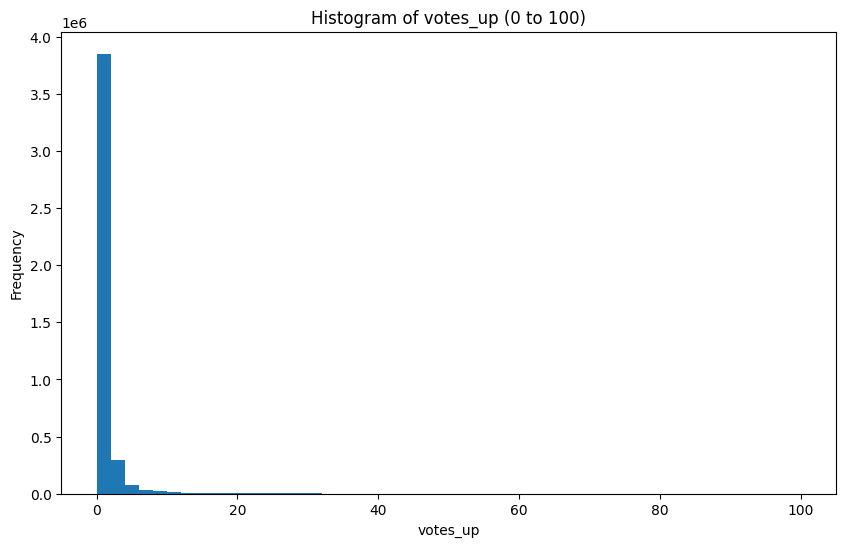

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(target[target <= 100], bins=50)
plt.xlabel('votes_up')
plt.ylabel('Frequency')
plt.title('Histogram of votes_up (0 to 100)')
plt.show()

**5.1.4 Log-Transformed Distribution**

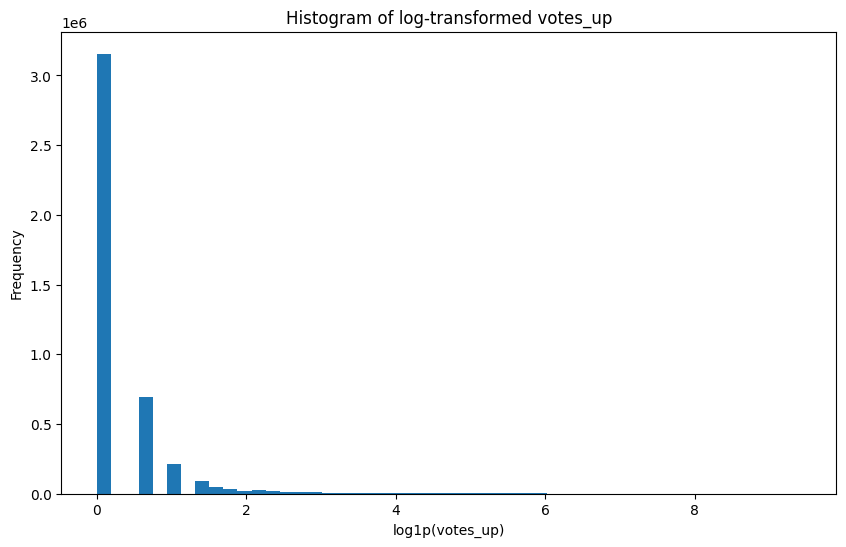

In [20]:
log_target = np.log1p(target)

plt.figure(figsize=(10, 6))
plt.hist(log_target, bins=50)
plt.xlabel('log1p(votes_up)')
plt.ylabel('Frequency')
plt.title('Histogram of log-transformed votes_up')
plt.show()

**5.1.5 Compare Raw vs Log-Transformed Distribution**

In [21]:
print("Skewness comparison:")
print(f"Raw votes_up skewness: {target.skew():.4f}")
print(f"log1p(votes_up) skewness: {log_target.skew():.4f}")

Skewness comparison:
Raw votes_up skewness: 112.3560
log1p(votes_up) skewness: 3.3880


**5.1.6 Line Plot of Frequency Distribution**

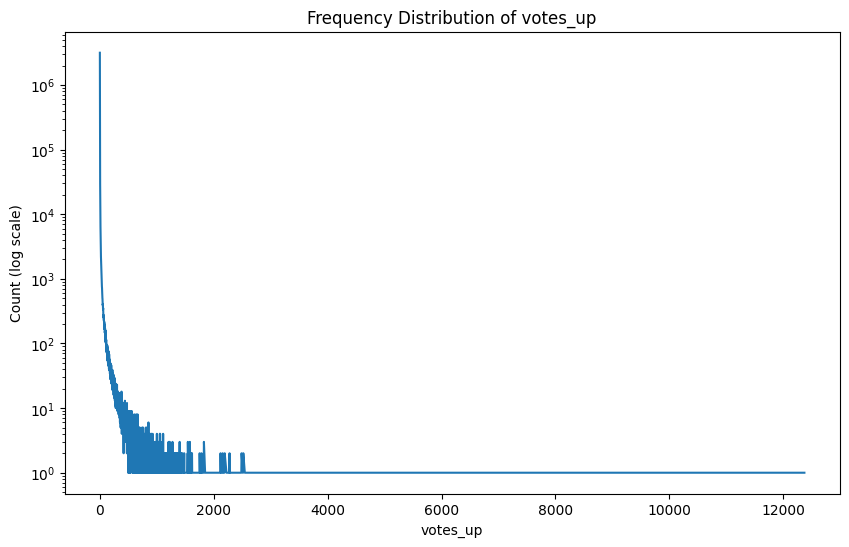

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(counts['votes_up'], counts['count'])
plt.yscale('log')
plt.xlabel('votes_up')
plt.ylabel('Count (log scale)')
plt.title('Frequency Distribution of votes_up')
plt.show()

The target variable `votes_up` is highly right-skewed, with a large proportion of reviews receiving very few helpful votes, especially zero. This indicates a heavy-tailed distribution. To better understand the shape of the distribution, a log transformation using `log1p(votes_up)` was applied, which reduces skewness and makes the distribution more suitable for modeling.

## 5.2 Text Analysis
	•	Review length distribution
	•	Word count distribution
	•	Relationship with helpful votes

**5.2.1 Review Length Distribution & Word count distribution**



In [23]:
# Create text feature columns on df (used throughout Part 5.2)
if "review_length" not in df.columns:
    df["review"] = df["review"].fillna("").astype(str)
    df["review_length"] = df["review"].str.len()

if "word_count" not in df.columns:
    df["word_count"] = df["review"].str.split().str.len()

if "is_helpful" not in df.columns:
    df["is_helpful"] = (df["votes_up"] > 0).astype(int)

print("Review length summary statistics (characters):")
print(df["review_length"].describe())
print(f"\nMedian review length: {df['review_length'].median():.0f} characters")
print(f"Reviews with length > 1000: {(df['review_length'] > 1000).mean():.2%}")

Review length summary statistics (characters):
count    3.957528e+06
mean     1.813964e+02
std      6.654711e+03
min      1.000000e+00
25%      1.300000e+01
50%      4.200000e+01
75%      1.400000e+02
max      7.705631e+06
Name: review_length, dtype: float64

Median review length: 42 characters
Reviews with length > 1000: 3.42%


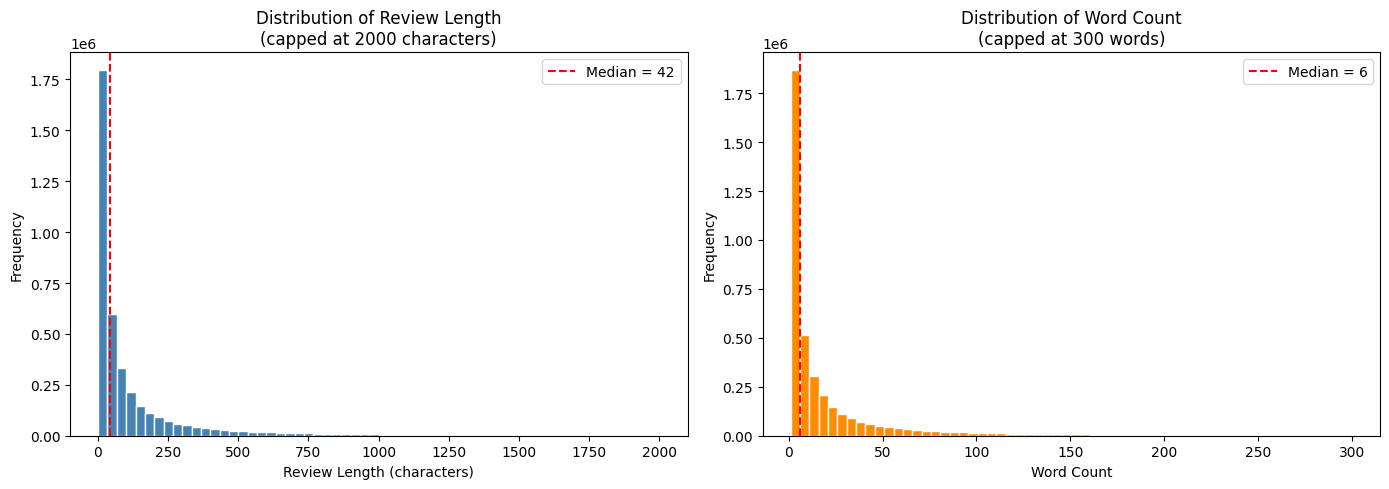


Word count summary:
count    3.957528e+06
mean     3.007830e+01
std      5.930763e+02
min      1.000000e+00
25%      2.000000e+00
50%      6.000000e+00
75%      2.300000e+01
max      6.885000e+05
Name: word_count, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Review Length (characters)
axes[0].hist(df["review_length"][df["review_length"] <= 2000], bins=60, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Review Length (characters)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Review Length\n(capped at 2000 characters)")
axes[0].axvline(df["review_length"].median(), color="red", linestyle="--", label=f"Median = {df['review_length'].median():.0f}")
axes[0].legend()

# Right: Word Count
axes[1].hist(df["word_count"][df["word_count"] <= 300], bins=60, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Word Count\n(capped at 300 words)")
axes[1].axvline(df["word_count"].median(), color="red", linestyle="--", label=f"Median = {df['word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nWord count summary:")
print(df["word_count"].describe())


**5.2.2 Relationship Between Review Length and Helpfulness**

C:\Users\Administrator\AppData\Local\Temp\ipykernel_24496\2890419131.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([not_helpful_lengths, helpful_lengths], labels=["Not Helpful\n(votes_up=0)", "Helpful\n(votes_up>0)"])


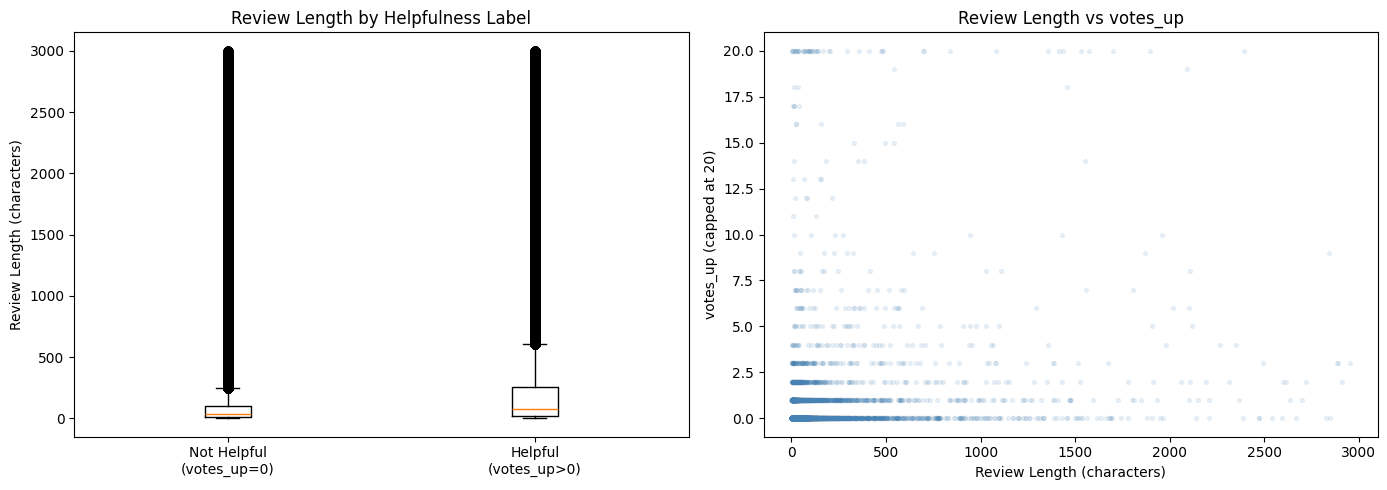

Pearson correlation — review_length vs votes_up : 0.0059
Pearson correlation — word_count    vs votes_up : 0.0100


In [25]:
df["word_count"] = df["review"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Box plot — review_length by helpfulness label
df_plot = df[df["review_length"] <= 3000].copy()
helpful_lengths = df_plot[df_plot["is_helpful"] == 1]["review_length"]
not_helpful_lengths = df_plot[df_plot["is_helpful"] == 0]["review_length"]

axes[0].boxplot([not_helpful_lengths, helpful_lengths], labels=["Not Helpful\n(votes_up=0)", "Helpful\n(votes_up>0)"])
axes[0].set_ylabel("Review Length (characters)")
axes[0].set_title("Review Length by Helpfulness Label")

# Right: Scatter — review_length vs votes_up (capped)
sample = df_plot.sample(min(5000, len(df_plot)), random_state=42)
axes[1].scatter(sample["review_length"], sample["votes_up"].clip(upper=20), alpha=0.1, s=8, color="steelblue")
axes[1].set_xlabel("Review Length (characters)")
axes[1].set_ylabel("votes_up (capped at 20)")
axes[1].set_title("Review Length vs votes_up")

plt.tight_layout()
plt.show()

corr = df["review_length"].corr(df["votes_up"])
word_corr = df["word_count"].corr(df["votes_up"])
print(f"Pearson correlation — review_length vs votes_up : {corr:.4f}")
print(f"Pearson correlation — word_count    vs votes_up : {word_corr:.4f}")

## 5.3 Reviewer Behavior
	•	Number of reviews per user
	•	Playtime distribution
	•	Activity vs helpfulness

**5.3.1 Number of Reviews per User**

num_reviews summary statistics:
count    3.957528e+06
mean     1.032324e+01
std      3.235699e+01
min      1.000000e+00
25%      2.000000e+00
50%      4.000000e+00
75%      1.000000e+01
max      5.236000e+03
Name: num_reviews, dtype: float64

Median num_reviews: 4
Proportion with num_reviews == 1: 21.17%
Proportion with num_reviews > 100: 0.93%


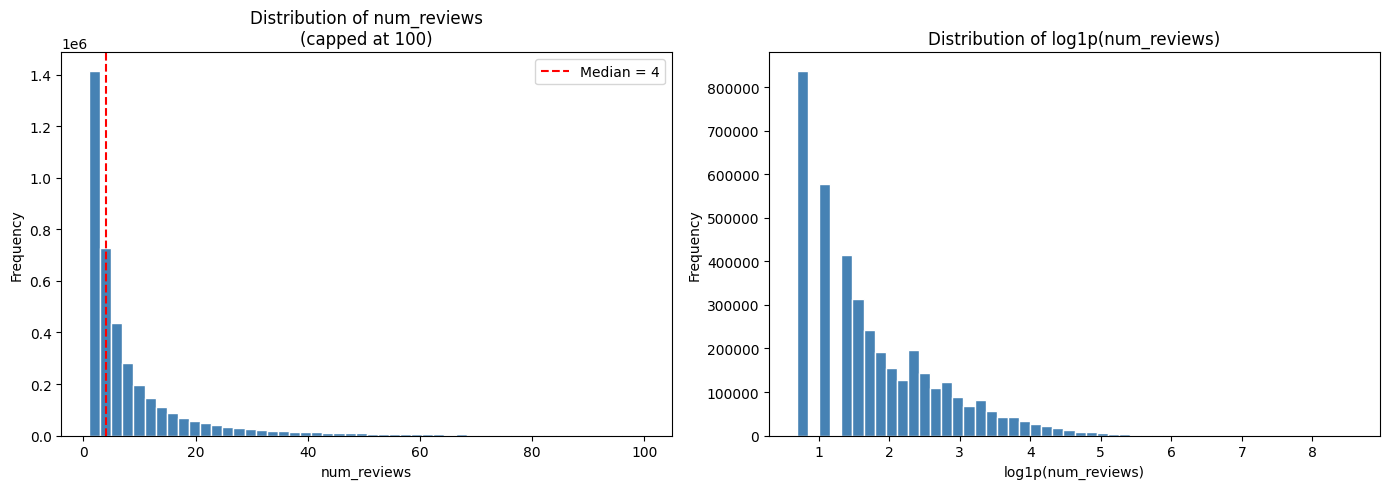

In [26]:
if "num_reviews" in df.columns:
    nr = df["num_reviews"].dropna()
    print("num_reviews summary statistics:")
    print(nr.describe())
    print(f"\nMedian num_reviews: {nr.median():.0f}")
    print(f"Proportion with num_reviews == 1: {(nr == 1).mean():.2%}")
    print(f"Proportion with num_reviews > 100: {(nr > 100).mean():.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distribution (capped for readability)
    axes[0].hist(nr[nr <= 100], bins=50, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("num_reviews")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Distribution of num_reviews\n(capped at 100)")
    axes[0].axvline(nr.median(), color="red", linestyle="--",
                    label=f"Median = {nr.median():.0f}")
    axes[0].legend()

    # Right: Log-scale to show full range
    axes[1].hist(np.log1p(nr), bins=50, color="steelblue", edgecolor="white")
    axes[1].set_xlabel("log1p(num_reviews)")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Distribution of log1p(num_reviews)")

    plt.tight_layout()
    plt.show()
else:
    print("num_reviews column not found in df.")

**5.3.2 Playtime Distribution**

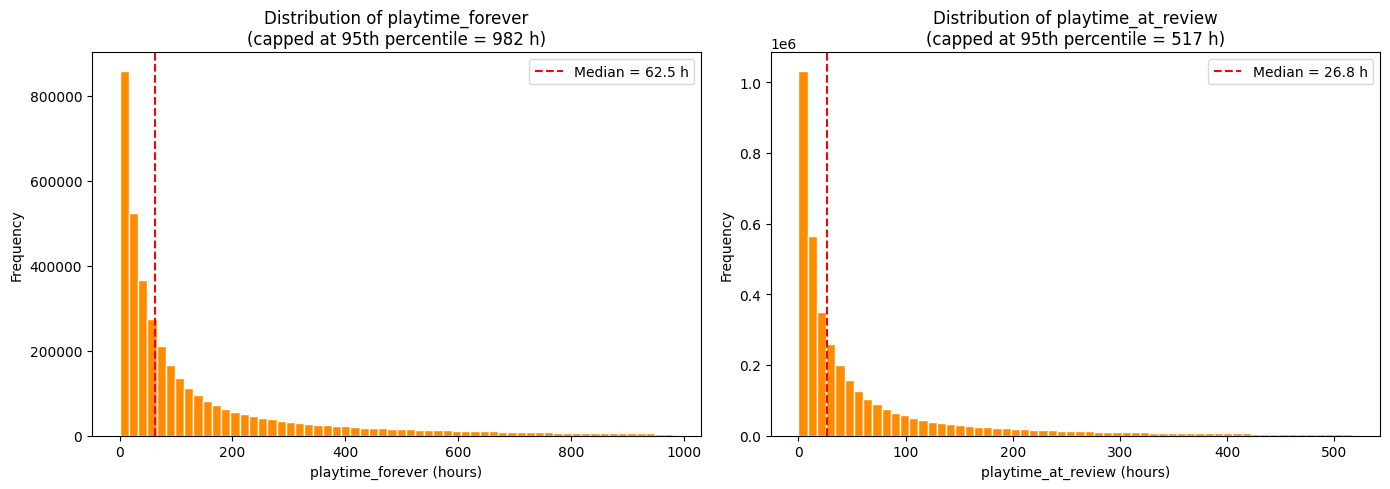

Playtime statistics (hours):

  playtime_forever:
    Median : 62.5 h
    Mean   : 220.3 h
    p95    : 982.1 h
    Max    : 39764.8 h

  playtime_at_review:
    Median : 26.8 h
    Mean   : 113.9 h
    p95    : 517.0 h
    Max    : 27021.6 h


In [27]:
# playtime_forever: total hours played (in minutes in Steam API — convert to hours)
# playtime_at_review: hours played at the time the review was written
playtime_cols = [c for c in ["playtime_forever", "playtime_at_review"] if c in df.columns]

if playtime_cols:
    fig, axes = plt.subplots(1, len(playtime_cols), figsize=(7 * len(playtime_cols), 5))
    if len(playtime_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, playtime_cols):
        # Convert minutes → hours
        hours = df[col].dropna() / 60
        cap = hours.quantile(0.95)
        ax.hist(hours[hours <= cap], bins=60, color="darkorange", edgecolor="white")
        ax.set_xlabel(f"{col} (hours)")
        ax.set_ylabel("Frequency")
        ax.set_title(f"Distribution of {col}\n(capped at 95th percentile = {cap:.0f} h)")
        ax.axvline(hours.median(), color="red", linestyle="--",
                   label=f"Median = {hours.median():.1f} h")
        ax.legend()

    plt.tight_layout()
    plt.show()

    print("Playtime statistics (hours):")
    for col in playtime_cols:
        hours = df[col].dropna() / 60
        print(f"\n  {col}:")
        print(f"    Median : {hours.median():.1f} h")
        print(f"    Mean   : {hours.mean():.1f} h")
        print(f"    p95    : {hours.quantile(0.95):.1f} h")
        print(f"    Max    : {hours.max():.1f} h")
else:
    print("No playtime columns found in df.")

**5.3.3 Reviewer Activity vs Helpfulness**

C:\Users\Administrator\AppData\Local\Temp\ipykernel_24496\346631188.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_24496\346631188.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


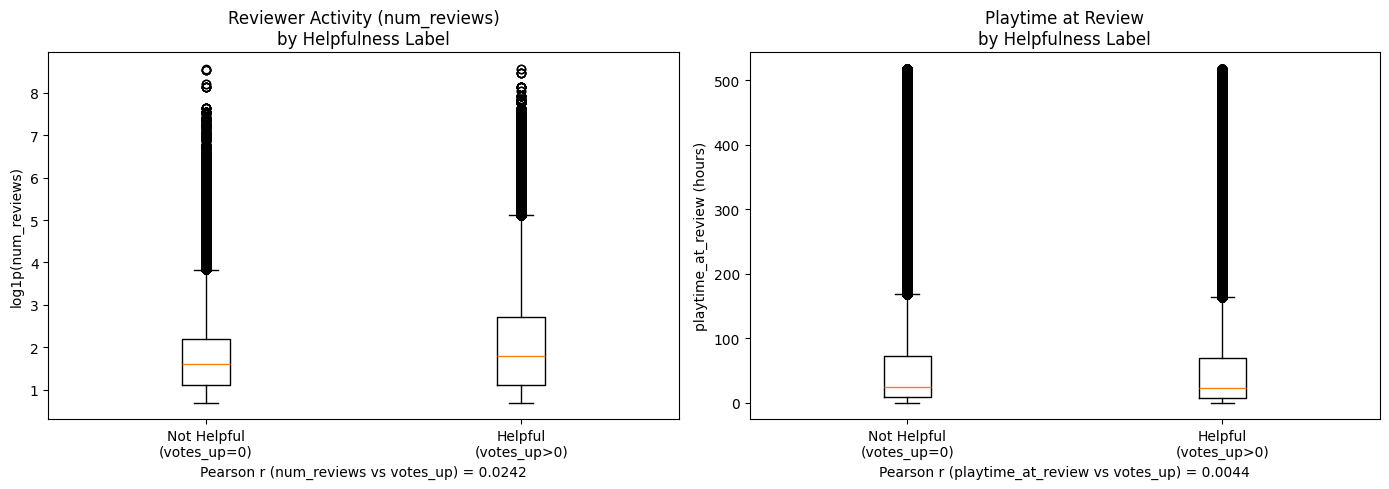

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: num_reviews vs votes_up ──────────────────────────────────────────────
if "num_reviews" in df.columns:
    plot_df = df[["num_reviews", "votes_up", "is_helpful"]].dropna()
    helpful_nr = plot_df[plot_df["is_helpful"] == 1]["num_reviews"]
    not_helpful_nr = plot_df[plot_df["is_helpful"] == 0]["num_reviews"]
    axes[0].boxplot(
        [np.log1p(not_helpful_nr), np.log1p(helpful_nr)],
        labels=["Not Helpful\n(votes_up=0)", "Helpful\n(votes_up>0)"]
    )
    axes[0].set_ylabel("log1p(num_reviews)")
    axes[0].set_title("Reviewer Activity (num_reviews)\nby Helpfulness Label")
    corr_nr = df["num_reviews"].corr(df["votes_up"])
    axes[0].set_xlabel(f"Pearson r (num_reviews vs votes_up) = {corr_nr:.4f}")
else:
    axes[0].text(0.5, 0.5, "num_reviews not available", ha="center", va="center")
    axes[0].set_title("num_reviews not found")

# ── Right: playtime_at_review vs votes_up ────────────────────────────────────
if "playtime_at_review" in df.columns:
    plot_df2 = df[["playtime_at_review", "votes_up", "is_helpful"]].dropna()
    # convert to hours and cap
    plot_df2 = plot_df2.copy()
    plot_df2["playtime_h"] = plot_df2["playtime_at_review"] / 60
    cap = plot_df2["playtime_h"].quantile(0.95)
    plot_df2 = plot_df2[plot_df2["playtime_h"] <= cap]

    helpful_pt = plot_df2[plot_df2["is_helpful"] == 1]["playtime_h"]
    not_helpful_pt = plot_df2[plot_df2["is_helpful"] == 0]["playtime_h"]
    axes[1].boxplot(
        [not_helpful_pt, helpful_pt],
        labels=["Not Helpful\n(votes_up=0)", "Helpful\n(votes_up>0)"]
    )
    axes[1].set_ylabel("playtime_at_review (hours)")
    axes[1].set_title("Playtime at Review\nby Helpfulness Label")
    corr_pt = df["playtime_at_review"].corr(df["votes_up"])
    axes[1].set_xlabel(f"Pearson r (playtime_at_review vs votes_up) = {corr_pt:.4f}")
else:
    axes[1].text(0.5, 0.5, "playtime_at_review not available", ha="center", va="center")
    axes[1].set_title("playtime_at_review not found")

plt.tight_layout()
plt.show()

**5.3.4 Correlation Summary — Reviewer Features**

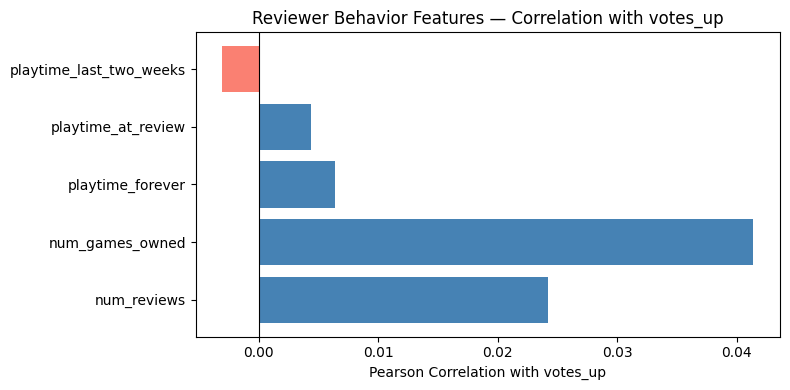


Correlations with votes_up:
  num_reviews                          r = 0.0242
  num_games_owned                      r = 0.0414
  playtime_forever                     r = 0.0064
  playtime_at_review                   r = 0.0044
  playtime_last_two_weeks              r = -0.0030


In [29]:
reviewer_cols = [c for c in [
    "num_reviews", "num_games_owned",
    "playtime_forever", "playtime_at_review", "playtime_last_two_weeks"
] if c in df.columns]

if reviewer_cols:
    corr_series = df[reviewer_cols + ["votes_up"]].corr()["votes_up"].drop("votes_up")
    corr_df_plot = corr_series.reset_index()
    corr_df_plot.columns = ["feature", "correlation_with_votes_up"]

    plt.figure(figsize=(8, 4))
    colors = ["steelblue" if v >= 0 else "salmon" for v in corr_df_plot["correlation_with_votes_up"]]
    plt.barh(corr_df_plot["feature"], corr_df_plot["correlation_with_votes_up"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("Pearson Correlation with votes_up")
    plt.title("Reviewer Behavior Features — Correlation with votes_up")
    plt.tight_layout()
    plt.show()

    print("\nCorrelations with votes_up:")
    for _, row in corr_df_plot.iterrows():
        print(f"  {row['feature']:35s}  r = {row['correlation_with_votes_up']:.4f}")
else:
    print("No reviewer behavior columns found in df.")

## 5.4 Game-level Analysis
	•	Genre vs helpfulness
	•	Price vs helpfulness
	•	Time since release

	This section examines game-level attributes merged from the `games` dataset:
	review language distribution, game price, time elapsed since release,
	and game popularity indicators. The dataset spans **80 games**,
	so these attributes vary meaningfully across reviews and can serve
	as valuable predictive features.

**5.4.1 Review Language Distribution**

Total unique languages: 28

Top 15 languages (by review count):
language
english      1746997
schinese      656038
russian       367041
german        160311
brazilian     156338
spanish       152903
turkish       138891
french        112467
polish        106934
koreana       102300
tchinese       35969
italian        28467
czech          26975
thai           22930
japanese       18724

Coverage of top 15 languages: 96.86%


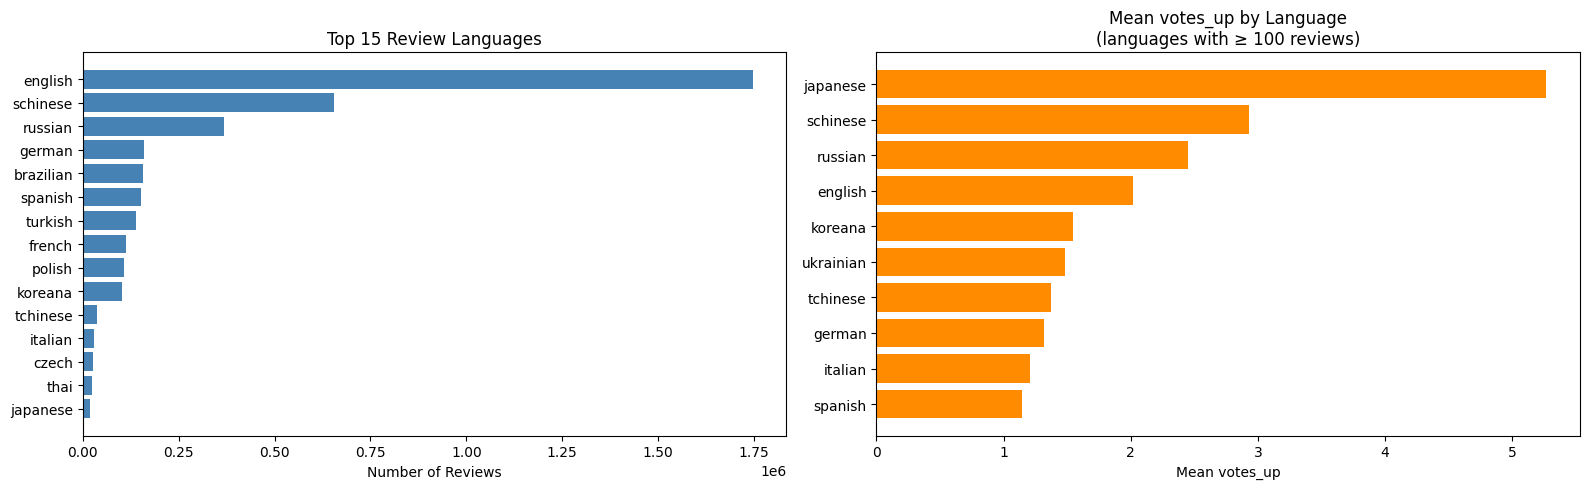

In [38]:
if "language" in df.columns:
    lang_counts = df["language"].value_counts()
    top_n = 15

    print(f"Total unique languages: {lang_counts.shape[0]}")
    print(f"\nTop {top_n} languages (by review count):")
    print(lang_counts.head(top_n).to_string())
    print(f"\nCoverage of top {top_n} languages: {lang_counts.head(top_n).sum() / len(df):.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: bar chart of top languages
    top_langs = lang_counts.head(top_n)
    axes[0].barh(top_langs.index[::-1], top_langs.values[::-1], color="steelblue")
    axes[0].set_xlabel("Number of Reviews")
    axes[0].set_title(f"Top {top_n} Review Languages")

    # Right: mean votes_up by language (top 10 with enough reviews)
    lang_helpfulness = (
        df.groupby("language")["votes_up"]
        .agg(["mean", "count"])
        .query("count >= 100")
        .sort_values("mean", ascending=False)
        .head(10)
    )
    axes[1].barh(lang_helpfulness.index[::-1], lang_helpfulness["mean"][::-1], color="darkorange")
    axes[1].set_xlabel("Mean votes_up")
    axes[1].set_title("Mean votes_up by Language\n(languages with ≥ 100 reviews)")

    plt.tight_layout()
    plt.show()
else:
    print("'language' column not found in df.")

**5.4.2 Game Price**

Number of unique games: 70
Number of unique price points: 17

Price distribution across games:
count    70.000000
mean     21.957714
std      16.101426
min       0.000000
25%       9.990000
50%      18.990000
75%      29.990000
max      59.990000
Name: price, dtype: float64

Free games (price == 0): 3 games (4.3%)


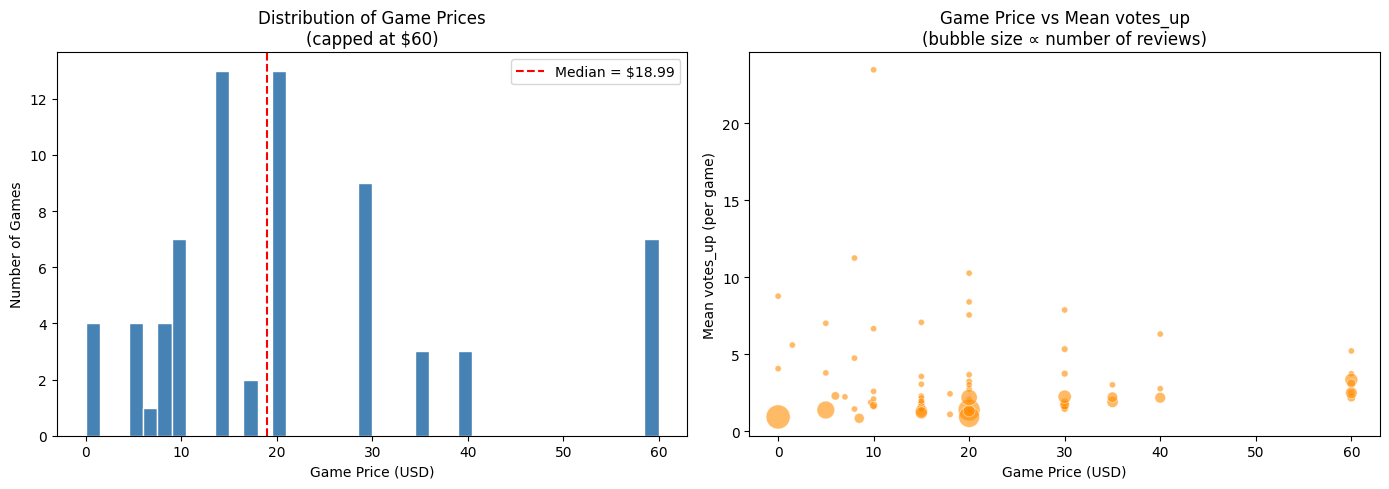


Pearson correlation — price vs votes_up: 0.0121
(Note: price is constant within each game, so this measures between-game variation)


In [39]:
if "price" in df.columns:
    # price is a game-level attribute — each game has a fixed price,
    # so all reviews for the same game share the same price value.
    # Use "name" as game identifier since "appid" was dropped after merging.
    game_key = "name" if "name" in df.columns else df.columns[0]

    price_per_game = df.groupby(game_key)["price"].first().dropna()
    print(f"Number of unique games: {price_per_game.shape[0]}")
    print(f"Number of unique price points: {price_per_game.nunique()}")
    print(f"\nPrice distribution across games:")
    print(price_per_game.describe())
    print(f"\nFree games (price == 0): {(price_per_game == 0).sum()} games ({(price_per_game == 0).mean():.1%})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distribution of game prices
    axes[0].hist(price_per_game[price_per_game <= 60], bins=40, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Game Price (USD)")
    axes[0].set_ylabel("Number of Games")
    axes[0].set_title("Distribution of Game Prices\n(capped at $60)")
    axes[0].axvline(price_per_game.median(), color="red", linestyle="--",
                    label=f"Median = ${price_per_game.median():.2f}")
    axes[0].legend()

    # Right: Mean votes_up per game vs price (scatter)
    game_stats = df.groupby(game_key).agg(
        mean_votes_up=("votes_up", "mean"),
        price=("price", "first"),
        n_reviews=("votes_up", "count")
    ).dropna()
    # Size proportional to number of reviews
    size = np.clip(game_stats["n_reviews"] / game_stats["n_reviews"].max() * 300, 20, 300)
    axes[1].scatter(game_stats["price"], game_stats["mean_votes_up"],
                    alpha=0.6, s=size, color="darkorange", edgecolors="white", linewidth=0.5)
    axes[1].set_xlabel("Game Price (USD)")
    axes[1].set_ylabel("Mean votes_up (per game)")
    axes[1].set_title("Game Price vs Mean votes_up\n(bubble size ∝ number of reviews)")

    plt.tight_layout()
    plt.show()

    corr_price = df["price"].corr(df["votes_up"])
    print(f"\nPearson correlation — price vs votes_up: {corr_price:.4f}")
    print("(Note: price is constant within each game, so this measures between-game variation)")
else:
    print("'price' column not found in df.")


**5.4.3 Time Since Release**

In [40]:
# Compute days_since_release = review creation date - game release date
if "review_created_dt" in df.columns and "release_date_dt" in df.columns:
    df["days_since_release"] = (
        df["review_created_dt"] - df["release_date_dt"]
    ).dt.days

    valid = df["days_since_release"].dropna()
    valid = valid[valid >= 0]   # drop any negative (data anomalies)

    print("days_since_release summary statistics:")
    print(valid.describe())
    print(f"\nMedian: {valid.median():.0f} days ({valid.median()/365:.1f} years)")
    print(f"Reviews written within 1 year of release: {(valid <= 365).mean():.2%}")
    print(f"Reviews written within 3 years of release: {(valid <= 1095).mean():.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distribution of days_since_release
    cap_days = valid.quantile(0.97)
    axes[0].hist(valid[valid <= cap_days], bins=60, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Days Since Release")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(f"Distribution of Days Since Release\n(capped at 97th percentile = {cap_days:.0f} days)")
    axes[0].axvline(valid.median(), color="red", linestyle="--",
                    label=f"Median = {valid.median():.0f} d")
    axes[0].legend()

    # Right: Mean votes_up by days_since_release (binned into quarters)
    df_valid = df[df["days_since_release"].notna() & (df["days_since_release"] >= 0)].copy()
    df_valid["release_bin"] = pd.cut(
        df_valid["days_since_release"],
        bins=[0, 30, 90, 180, 365, 730, 1825, df_valid["days_since_release"].max() + 1],
        labels=["0–30d", "31–90d", "91–180d", "181d–1y", "1–2y", "2–5y", ">5y"]
    )
    bin_stats = df_valid.groupby("release_bin", observed=True)["votes_up"].mean()

    axes[1].bar(bin_stats.index.astype(str), bin_stats.values, color="darkorange")
    axes[1].set_xlabel("Time Since Release")
    axes[1].set_ylabel("Mean votes_up")
    axes[1].set_title("Mean votes_up by Time Since Release")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

    corr_dsr = df["days_since_release"].corr(df["votes_up"])
    print(f"\nPearson correlation — days_since_release vs votes_up: {corr_dsr:.4f}")
else:
    print("review_created_dt or release_date_dt not available in df.")

review_created_dt or release_date_dt not available in df.


**5.4.4 Game Popularity Indicators**

Game-level popularity indicators (unique values per game):
  positive                        games:  70,  min: 0,  median: 29,542,  max: 855,816
  negative                        games:  70,  min: 0,  median: 3,937,  max: 164,105
  negative                        games:  70,  min: 0,  median: 3,937,  max: 164,105

  Corr (game-level mean votes_up vs positive): r = -0.3080

  Corr (game-level mean votes_up vs negative): r = -0.1224

  Corr (game-level mean votes_up vs positive): r = -0.3080

  Corr (game-level mean votes_up vs negative): r = -0.1224


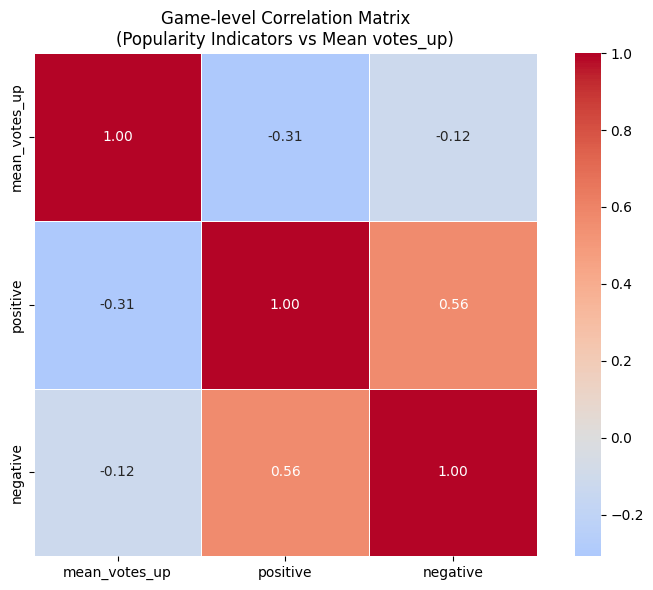

In [42]:
pop_cols = [c for c in ["positive", "negative", "recommendations", "pct_pos_total",
                         "average_playtime_forever", "peak_ccu", "metacritic_score"] if c in df.columns]

# Use "name" as game identifier since "appid" was dropped after merging
game_key = "name" if "name" in df.columns else df.columns[0]

if pop_cols:
    # These are game-level metrics — vary across games, constant within a game
    print("Game-level popularity indicators (unique values per game):")
    for col in pop_cols:
        vals = df.groupby(game_key)[col].first().dropna()
        print(f"  {col:30s}  games: {len(vals):3d},  min: {vals.min():,.0f},  "
              f"median: {vals.median():,.0f},  max: {vals.max():,.0f}")

    # Correlation with mean votes_up per game
    game_agg = df.groupby(game_key).agg(mean_votes_up=("votes_up", "mean"))
    for col in pop_cols:
        game_col = df.groupby(game_key)[col].first()
        merged = game_agg.join(game_col, how="inner").dropna()
        r = merged["mean_votes_up"].corr(merged[col])
        print(f"\n  Corr (game-level mean votes_up vs {col}): r = {r:.4f}")

    # Heatmap of game-level correlations
    game_level = df.groupby(game_key).agg(
        mean_votes_up=("votes_up", "mean"),
        **{col: (col, "first") for col in pop_cols}
    ).dropna()

    plt.figure(figsize=(8, 6))
    sns.heatmap(game_level.corr(), annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5, square=True)
    plt.title("Game-level Correlation Matrix\n(Popularity Indicators vs Mean votes_up)")
    plt.tight_layout()
    plt.show()
else:
    print("No popularity indicator columns found in df.")


# Part 6: Feature Engineering

## 6.1 Temporal Features


In [43]:
# Days between review time and game release
df["days_since_release"] = (df["timestamp_created_dt"] - df["release_date_dt"]).dt.days

# Log transform (handle negatives and missing values)
df["days_since_release_log"] = np.log1p(
    df["days_since_release"].clip(lower=0).fillna(0).astype(float)
)

# Summary stats
print("days_since_release (raw days):\n", df["days_since_release"].describe())
print("\ndays_since_release_log:\n", df["days_since_release_log"].describe())

days_since_release (raw days):
 count    3.957528e+06
mean     7.256611e+02
std      8.355054e+02
min     -2.191000e+03
25%      1.100000e+02
50%      5.620000e+02
75%      1.272000e+03
max      3.664000e+03
Name: days_since_release, dtype: float64

days_since_release_log:
 count    3.957528e+06
mean     5.434057e+00
std      2.395809e+00
min      0.000000e+00
25%      4.709530e+00
50%      6.333280e+00
75%      7.149132e+00
max      8.206584e+00
Name: days_since_release_log, dtype: float64


## 6.2 Reviewer Features

In [44]:
# Columns to apply log transform
LOG_REVIEW_COLS = [
    "playtime_forever",
    "playtime_at_review",
    "playtime_last_two_weeks",
    "num_games_owned",
    "num_reviews",
]

for col in LOG_REVIEW_COLS:
    # Convert to numeric, handle invalid/missing values, remove negatives, then apply log(1+x)
    df[col + "_log"] = np.log1p(
        pd.to_numeric(df[col], errors="coerce").clip(lower=0).fillna(0)
    )

# Show which new log features were created
print("Added:", [c + "_log" for c in LOG_REVIEW_COLS if c in df.columns])

Added: ['playtime_forever_log', 'playtime_at_review_log', 'playtime_last_two_weeks_log', 'num_games_owned_log', 'num_reviews_log']


## 6.3 Numerical feature selection

In [45]:
import numpy as np

corr = df.corr(numeric_only=True)["votes_up"].sort_values(ascending=False)
print(corr.head(20))

corr_matrix = df.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Highly correlated columns:", to_drop)


votes_up                       1.000000
is_helpful                     0.094776
num_games_owned                0.041416
num_games_owned_log            0.037803
num_reviews_log                0.031581
num_reviews                    0.024190
price                          0.012118
written_during_early_access    0.011357
word_count                     0.009964
playtime_forever               0.006383
review_length                  0.005892
playtime_at_review             0.004369
required_age                   0.000815
received_for_free             -0.000991
playtime_last_two_weeks       -0.003046
playtime_at_review_log        -0.004862
playtime_forever_log          -0.005195
steam_purchase                -0.006115
negative                      -0.009573
playtime_last_two_weeks_log   -0.010663
Name: votes_up, dtype: float64
Highly correlated columns: ['word_count']
Highly correlated columns: ['word_count']


Correlation analysis shows that individual numerical features have weak linear relationships with the target variable (votes_up). This suggests that helpfulness is influenced by more complex and nonlinear patterns, especially textual features.

## 6.4 Game Metadata


In [46]:
import ast

# Extract the first genre from a string/list; fallback to "Unknown"
def primary_genre(val):
    if pd.isna(val):
        return "Unknown"
    s = str(val).strip()
    try:
        if s.startswith("["):                 # e.g., "['Action', 'RPG']"
            g = ast.literal_eval(s)           # safely parse to list
            return g[0] if g else "Unknown"   # take first genre
    except Exception:
        pass
    return "Unknown"

# Create primary genre column
df["genre_primary"] = df["genres"].map(primary_genre)

# Keep top 12 genres, group others as "Other"
top_g = df["genre_primary"].value_counts().nlargest(12).index
df["genre_primary"] = df["genre_primary"].where(df["genre_primary"].isin(top_g), "Other")

# One-hot encode genres
genre_dummies = pd.get_dummies(df["genre_primary"], prefix="genre", dtype="int8")
df = pd.concat([df, genre_dummies], axis=1)

print("Genre dummy columns:", list(genre_dummies.columns))

# Log-transform price (handle missing/non-numeric as 0)
df["price_log"] = np.log1p(pd.to_numeric(df["price"], errors="coerce").fillna(0))

# Summary statistics
print("\nprice_log describe:\n", df["price_log"].describe())

Genre dummy columns: ['genre_Action', 'genre_Adventure', 'genre_Casual', 'genre_Indie', 'genre_RPG', 'genre_Simulation', 'genre_Strategy']

price_log describe:
 count    3.957528e+06
mean     2.687549e+00
std      1.186317e+00
min      0.000000e+00
25%      2.369309e+00
50%      3.044046e+00
75%      3.433665e+00
max      4.110710e+00
Name: price_log, dtype: float64


## 6.5 Text Features
- TF-IDF is applied to review_cleaned, using only the training set for fitting to avoid data leakage. For multilingual data, character n-grams are used to better capture non-English text.
- BERT sentence embeddings are generated on the same train/test split. The English pipeline uses all-MiniLM-L6-v2, while the multilingual pipeline uses paraphrase-multilingual-MiniLM-L12-v2 to support multiple languages.
- Length-based features include review_len (character count).

In [47]:
# Count the amount of reviews in different languages
language_counts = df["language"].value_counts()
print("\nCounts of reviews per language:")
display(language_counts)


Counts of reviews per language:


language
english       1746997
schinese       656038
russian        367041
german         160311
brazilian      156338
spanish        152903
turkish        138891
french         112467
polish         106934
koreana        102300
tchinese        35969
italian         28467
czech           26975
thai            22930
japanese        18724
portuguese      18518
dutch           16619
swedish         14413
latam           13719
hungarian       13317
romanian        11431
danish          10540
finnish          9175
norwegian        7456
ukrainian        3440
greek            2467
bulgarian        2346
vietnamese        802
Name: count, dtype: int64

### 6.5.1 English-only reviews

In [48]:
!pip3 install -U sentence-transformers


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

# Constants
RANDOM_STATE = 42
TEST_SIZE = 0.2
HELPFUL_THRESHOLD = 5

def clean_review_text_en(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Filter English reviews
df_en = df.copy()
df_en["language"] = df_en["language"].fillna("").astype(str).str.lower()

english_aliases = {"english", "en"}
df_en = df_en[df_en["language"].isin(english_aliases)].copy()

print("English-only shape:", df_en.shape)

# Build target
df_en["votes_up"] = pd.to_numeric(df_en["votes_up"], errors="coerce").fillna(0)
df_en["is_helpful"] = (df_en["votes_up"] >= HELPFUL_THRESHOLD).astype(int)
df_en["target_log"] = np.log1p(df_en["votes_up"])

# Downsample negatives
pos_df_en = df_en[df_en["is_helpful"] == 1]
neg_df_en = df_en[df_en["is_helpful"] == 0]

n_pos_en = len(pos_df_en)
n_neg_en = len(neg_df_en)

neg_sampled_en = neg_df_en.sample(
    n=min(n_pos_en, n_neg_en),
    random_state=RANDOM_STATE
)

df_en = pd.concat([pos_df_en, neg_sampled_en], axis=0).sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("English-only after negative sampling:")
print(df_en["is_helpful"].value_counts())

# Text processing
df_en["review"] = df_en["review"].fillna("").astype(str)
df_en["review_cleaned"] = df_en["review"].map(clean_review_text_en)
df_en["review_len"] = df_en["review_cleaned"].str.len()

y_raw_en = df_en["votes_up"].values
y_cls_en = df_en["is_helpful"].values

# Train/test split
idx_en = np.arange(len(df_en))
train_idx_en, test_idx_en = train_test_split(
    idx_en,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_cls_en
)

# TF-IDF for English
text_tr_en = df_en["review_cleaned"].iloc[train_idx_en]
text_te_en = df_en["review_cleaned"].iloc[test_idx_en]

tfidf_vectorizer_en = TfidfVectorizer(
    max_features=5000,
    sublinear_tf=True,
    min_df=5,
    ngram_range=(1, 2),
    stop_words="english"
)

X_tfidf_train_en = tfidf_vectorizer_en.fit_transform(text_tr_en)
X_tfidf_test_en = tfidf_vectorizer_en.transform(text_te_en)

print("English TF-IDF shapes:", X_tfidf_train_en.shape, X_tfidf_test_en.shape)

# Display IDF values of the first 10 words
for word, val in zip(
    tfidf_vectorizer_en.get_feature_names_out()[:10],
    tfidf_vectorizer_en.idf_[:10]
):
    print(word, ":", val)

# Display TF-IDF values of the first 10 words
print(X_tfidf_train_en[:10].toarray())

# English BERT embeddings
BERT_MODEL_NAME_EN = "all-MiniLM-L6-v2"
BERT_CHAR_LIMIT = 2000

bert_en_model = SentenceTransformer(BERT_MODEL_NAME_EN)

raw_tr_en = df_en["review"].iloc[train_idx_en].astype(str).str[:BERT_CHAR_LIMIT].tolist()
raw_te_en = df_en["review"].iloc[test_idx_en].astype(str).str[:BERT_CHAR_LIMIT].tolist()

batch_size_en = 64 if len(df_en) <= 100_000 else 32

X_bert_train_en = bert_en_model.encode(
    raw_tr_en,
    batch_size=batch_size_en,
    show_progress_bar=True
)
X_bert_test_en = bert_en_model.encode(
    raw_te_en,
    batch_size=batch_size_en,
    show_progress_bar=True
)

print("English BERT shapes:", X_bert_train_en.shape, X_bert_test_en.shape)

print(df_en[["review_len", "votes_up", "is_helpful"]].describe().round(2).to_string())

d:\Github_Desktop_File\ECE-9612-Group-Project\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


English-only shape: (1746997, 46)
English-only after negative sampling:
is_helpful
1    67377
0    67377
Name: count, dtype: int64
English-only after negative sampling:
is_helpful
1    67377
0    67377
Name: count, dtype: int64
English TF-IDF shapes: (107803, 5000) (26951, 5000)
00 : 7.625225412260117
000 : 6.704747654031745
10 : 3.2120457549029098
10 10 : 4.093122460051106
10 20 : 7.6535961093893325
10 buy : 7.5318242371717155
10 game : 6.7679871121676625
10 h1 : 7.851871594125528
10 hours : 6.492245480087799
10 minutes : 6.747428385146626
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
English TF-IDF shapes: (107803, 5000) (26951, 5000)
00 : 7.625225412260117
000 : 6.704747654031745
10 : 3.2120457549029098
10 10 : 4.093122460051106
10 20 : 7.6535961093893325
10 buy : 7.5318242371717155
10 game : 6.7679871121676625
10 h1 : 7.851871594125528
10 hours : 6.492245480087799
10 minute

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8409.02it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8409.02it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 3369/3369 [06:21<00:00,  8.84it/s] 

Batches: 100%|██████████| 843/843 [01:37<00:00,  8.64it/s]



English BERT shapes: (107803, 384) (26951, 384)
       review_len   votes_up  is_helpful
count   134754.00  134754.00    134754.0
mean       460.09      21.41         0.5
std        915.68     136.71         0.5
min          0.00       0.00         0.0
25%         36.00       0.00         0.0
50%        126.00       4.50         0.5
75%        447.00       9.00         1.0
max       8000.00   12371.00         1.0


In [50]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(X_bert_train_en[:5])

print(sim)

[[0.9999999  0.341473   0.53441375 0.1617055  0.3812264 ]
 [0.341473   1.         0.24936901 0.10247316 0.2959408 ]
 [0.53441375 0.24936901 1.         0.0663968  0.2941791 ]
 [0.1617055  0.10247316 0.0663968  1.         0.1248031 ]
 [0.3812264  0.2959408  0.2941791  0.1248031  1.        ]]


In [51]:
print(X_bert_train_en[0][:10])

[ 0.03912086 -0.03599172  0.05739484 -0.05354203 -0.07901894  0.02427077
  0.0110683  -0.0302144   0.0137603   0.03453296]


### 6.5.2 Multilingual reviews

In [52]:
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

# Constants
RANDOM_STATE = 42
TEST_SIZE = 0.2
HELPFUL_THRESHOLD = 5

def clean_review_text_multi(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)   # keep multilingual characters
    text = re.sub(r"\s+", " ", text).strip()
    return text

#  Use all languages
df_multi = df.copy()

# Build target
df_multi["votes_up"] = pd.to_numeric(df_multi["votes_up"], errors="coerce").fillna(0)
df_multi["is_helpful"] = (df_multi["votes_up"] >= HELPFUL_THRESHOLD).astype(int)
df_multi["target_log"] = np.log1p(df_multi["votes_up"])

# Downsample negatives
pos_df_multi = df_multi[df_multi["is_helpful"] == 1]
neg_df_multi = df_multi[df_multi["is_helpful"] == 0]

n_pos_multi = len(pos_df_multi)
n_neg_multi = len(neg_df_multi)

neg_sampled_multi = neg_df_multi.sample(
    n=min(n_pos_multi, n_neg_multi),
    random_state=RANDOM_STATE
)

df_multi = pd.concat([pos_df_multi, neg_sampled_multi], axis=0).sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print("Multilingual after negative sampling:")
print(df_multi["is_helpful"].value_counts())

# Text processing
df_multi["review"] = df_multi["review"].fillna("").astype(str)
df_multi["review_cleaned"] = df_multi["review"].map(clean_review_text_multi)
df_multi["review_len"] = df_multi["review_cleaned"].str.len()

y_raw_multi = df_multi["votes_up"].values
y_cls_multi = df_multi["is_helpful"].values

# Train/test split
idx_multi = np.arange(len(df_multi))
train_idx_multi, test_idx_multi = train_test_split(
    idx_multi,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_cls_multi
)

# Multilingual-friendly TF-IDF
text_tr_multi = df_multi["review_cleaned"].iloc[train_idx_multi]
text_te_multi = df_multi["review_cleaned"].iloc[test_idx_multi]

tfidf_vectorizer_multi = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=5000,
    sublinear_tf=True,
    min_df=5,
)

X_tfidf_train_multi = tfidf_vectorizer_multi.fit_transform(text_tr_multi)
X_tfidf_test_multi = tfidf_vectorizer_multi.transform(text_te_multi)

print("Multilingual TF-IDF shapes:", X_tfidf_train_multi.shape, X_tfidf_test_multi.shape)

# Multilingual BERT embeddings
BERT_MODEL_NAME_MULTI = "paraphrase-multilingual-MiniLM-L12-v2"
BERT_CHAR_LIMIT = 2000

bert_multi_model = SentenceTransformer(BERT_MODEL_NAME_MULTI)

raw_tr_multi = df_multi["review"].iloc[train_idx_multi].astype(str).str[:BERT_CHAR_LIMIT].tolist()
raw_te_multi = df_multi["review"].iloc[test_idx_multi].astype(str).str[:BERT_CHAR_LIMIT].tolist()

batch_size_multi = 64 if len(df_multi) <= 100_000 else 32

X_bert_train_multi = bert_multi_model.encode(
    raw_tr_multi,
    batch_size=batch_size_multi,
    show_progress_bar=True
)
X_bert_test_multi = bert_multi_model.encode(
    raw_te_multi,
    batch_size=batch_size_multi,
    show_progress_bar=True
)

print("Multilingual BERT shapes:", X_bert_train_multi.shape, X_bert_test_multi.shape)

print(df_multi[["review_len", "votes_up", "is_helpful"]].describe().round(2).to_string())

Multilingual after negative sampling:
is_helpful
0    165233
1    165233
Name: count, dtype: int64
Multilingual TF-IDF shapes: (264372, 5000) (66094, 5000)
Multilingual TF-IDF shapes: (264372, 5000) (66094, 5000)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10380.91it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10380.91it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 8262/8262 [21:51<00:00,  6.30it/s]

Batches: 100%|██████████| 2066/2066 [05:27<00:00,  6.31it/s]



Multilingual BERT shapes: (264372, 384) (66094, 384)
       review_len   votes_up  is_helpful
count   330466.00  330466.00    330466.0
mean       377.17      19.18         0.5
std        833.13     112.43         0.5
min          0.00       0.00         0.0
25%         22.00       0.00         0.0
50%         82.00       4.50         0.5
75%        326.00      10.00         1.0
max       8000.00   12371.00         1.0


# Part 7: Modeling Approach

## 7.1 Baseline Model - Classification
	•	Linear Regression
	•	Purpose:
	•	Interpretability
	•	Benchmark performance

### 7.1.1 LogisticRegression on TF-IDF

In [54]:
# Baseline: LogisticRegression on TF-IDF
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

y_train_en = df_en["is_helpful"].iloc[train_idx_en].values
y_test_en = df_en["is_helpful"].iloc[test_idx_en].values

# L1 Logistic Regression
l1_clf = LogisticRegression(
    penalty="l1",         # Apply L1 regularization for feature selection
    solver="saga",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=3000,
    n_jobs=-1
)

# Hyperparameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

# Tune with cross-validation
grid = GridSearchCV(
    estimator=l1_clf,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_tfidf_train_en, y_train_en)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))

# Best model
best_l1_clf = grid.best_estimator_

# Test evaluation
y_proba_en = best_l1_clf.predict_proba(X_tfidf_test_en)[:, 1]
y_pred_en = best_l1_clf.predict(X_tfidf_test_en)

print("\nTuned L1 LogisticRegression + TF-IDF")
print("  Accuracy:", round(accuracy_score(y_test_en, y_pred_en), 4))
print("  F1:", round(f1_score(y_test_en, y_pred_en), 4))
print("  ROC-AUC:", round(roc_auc_score(y_test_en, y_proba_en), 4))
print()
print(classification_report(y_test_en, y_pred_en, digits=4))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


d:\Github_Desktop_File\ECE-9612-Group-Project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Github_Desktop_File\ECE-9612-Group-Project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\Github_Desktop_File\ECE-9612-Group-Project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Best parameters: {'C': 1}
Best CV F1: 0.7247

Tuned L1 LogisticRegression + TF-IDF
  Accuracy: 0.7365
  F1: 0.7246
  ROC-AUC: 0.8124

              precision    recall  f1-score   support

           0     0.7177    0.7799    0.7475     13476
           1     0.7590    0.6931    0.7246     13475

    accuracy                         0.7365     26951
   macro avg     0.7383    0.7365    0.7360     26951
weighted avg     0.7383    0.7365    0.7360     26951



### 7.1.2 LogisticRegression on BERT

In [55]:
# Baseline: LogisticRegression on BERT
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score

bert_clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

bert_clf.fit(X_bert_train_en, y_train_en)

y_proba_en = bert_clf.predict_proba(X_bert_test_en)[:, 1]
y_pred_en = bert_clf.predict(X_bert_test_en)

print("BERT + LogisticRegression")
print("  Accuracy:", round(accuracy_score(y_test_en, y_pred_en), 4))
print("  F1:", round(f1_score(y_test_en, y_pred_en), 4))
print("  ROC-AUC:", round(roc_auc_score(y_test_en, y_proba_en), 4))
print()
print(classification_report(y_test_en, y_pred_en, digits=4))

BERT + LogisticRegression
  Accuracy: 0.7369
  F1: 0.7382
  ROC-AUC: 0.8107

              precision    recall  f1-score   support

           0     0.7392    0.7321    0.7357     13476
           1     0.7347    0.7417    0.7382     13475

    accuracy                         0.7369     26951
   macro avg     0.7370    0.7369    0.7369     26951
weighted avg     0.7370    0.7369    0.7369     26951



### 7.1.3 LogisticRegression on TF-IDF and BERT

In [56]:
# Baseline: LogisticRegression on TF-IDF and BERT
import scipy.sparse as sp

# Convert BERT to sparse
X_bert_train_sparse = sp.csr_matrix(X_bert_train_en)
X_bert_test_sparse = sp.csr_matrix(X_bert_test_en)

# Combine features
X_train_combined = sp.hstack([X_tfidf_train_en, X_bert_train_sparse])
X_test_combined = sp.hstack([X_tfidf_test_en, X_bert_test_sparse])

combined_clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    solver="saga",
    n_jobs=-1,
)

combined_clf.fit(X_train_combined, y_train_en)

y_proba_en = combined_clf.predict_proba(X_test_combined)[:, 1]
y_pred_en = combined_clf.predict(X_test_combined)

print("TF-IDF + BERT + LogisticRegression")
print("  Accuracy:", round(accuracy_score(y_test_en, y_pred_en), 4))
print("  F1:", round(f1_score(y_test_en, y_pred_en), 4))
print("  ROC-AUC:", round(roc_auc_score(y_test_en, y_proba_en), 4))
print()
print(classification_report(y_test_en, y_pred_en, digits=4))

d:\Github_Desktop_File\ECE-9612-Group-Project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


TF-IDF + BERT + LogisticRegression
  Accuracy: 0.7478
  F1: 0.7449
  ROC-AUC: 0.8251

              precision    recall  f1-score   support

           0     0.7423    0.7592    0.7507     13476
           1     0.7536    0.7364    0.7449     13475

    accuracy                         0.7478     26951
   macro avg     0.7479    0.7478    0.7478     26951
weighted avg     0.7479    0.7478    0.7478     26951



### 7.1.4 LogisticRegression on TF-IDF + BERT + numeric features + category features

In [57]:
# TF-IDF + BERT + numeric features + category features
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# numeric features
numeric_cols = [
    "review_len",
    "price_log",
    "days_since_release_log",
    "playtime_forever_log",
    "playtime_at_review_log",
    "playtime_last_two_weeks_log",
    "num_reviews_log",
    "num_games_owned_log"
]

X_num_train = df_en.iloc[train_idx_en][numeric_cols].copy()
X_num_test = df_en.iloc[test_idx_en][numeric_cols].copy()

imputer = SimpleImputer(strategy="median")
X_num_train = imputer.fit_transform(X_num_train)
X_num_test = imputer.transform(X_num_test)

scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_test = scaler.transform(X_num_test)

X_num_train_sparse = sp.csr_matrix(X_num_train)
X_num_test_sparse = sp.csr_matrix(X_num_test)

# genre features
genre_cols = [c for c in df_en.columns if c.startswith("genre_") and c != "genre_primary"]

X_genre_train = df_en.iloc[train_idx_en][genre_cols]
X_genre_test = df_en.iloc[test_idx_en][genre_cols]
#X_genre_train_sparse = sp.csr_matrix(X_genre_train.values)
#X_genre_test_sparse = sp.csr_matrix(X_genre_test.values)
X_genre_train_sparse = sp.csr_matrix(X_genre_train.astype("int8").values)
X_genre_test_sparse = sp.csr_matrix(X_genre_test.astype("int8").values)

# BERT dense -> sparse
X_bert_train_sparse = sp.csr_matrix(X_bert_train_en)
X_bert_test_sparse = sp.csr_matrix(X_bert_test_en)

# final feature matrix
X_train_final_en = sp.hstack([
    X_tfidf_train_en,
    X_bert_train_sparse,
    X_num_train_sparse,
    X_genre_train_sparse
], format="csr")

X_test_final_en = sp.hstack([
    X_tfidf_test_en,
    X_bert_test_sparse,
    X_num_test_sparse,
    X_genre_test_sparse
], format="csr")

print(X_train_final_en.shape, X_test_final_en.shape)

(107803, 5399) (26951, 5399)


In [58]:
# LogisticRegression + TF-IDF + BERT + numeric + genre
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42,
    solver="saga",
    n_jobs=-1
)

clf.fit(X_train_final_en, y_train_en)

y_pred_en = clf.predict(X_test_final_en)
y_proba_en = clf.predict_proba(X_test_final_en)[:, 1]

print("LogisticRegression + TF-IDF + BERT + numeric + genre")
print("Accuracy:", round(accuracy_score(y_test_en, y_pred_en), 4))
print("F1:", round(f1_score(y_test_en, y_pred_en), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_en, y_proba_en), 4))
print()
print(classification_report(y_test_en, y_pred_en, digits=4))

d:\Github_Desktop_File\ECE-9612-Group-Project\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogisticRegression + TF-IDF + BERT + numeric + genre
Accuracy: 0.7697
F1: 0.7679
ROC-AUC: 0.8448

              precision    recall  f1-score   support

           0     0.7655    0.7775    0.7715     13476
           1     0.7740    0.7619    0.7679     13475

    accuracy                         0.7697     26951
   macro avg     0.7698    0.7697    0.7697     26951
weighted avg     0.7698    0.7697    0.7697     26951



### 7.1.5 RidgeClassifier on TF-IDF + BERT + numeric + genre

In [59]:
# RidgeClassifier + TF-IDF + BERT + numeric + genre
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score

ridge_clf = RidgeClassifier(
    alpha=1.0,
    class_weight="balanced",
    random_state=42
)

ridge_clf.fit(X_train_final_en, y_train_en)

y_pred_ridge_en = ridge_clf.predict(X_test_final_en)
y_score_ridge_en = ridge_clf.decision_function(X_test_final_en)

print("RidgeClassifier + TF-IDF + BERT + numeric + genre")
print("Accuracy:", round(accuracy_score(y_test_en, y_pred_ridge_en), 4))
print("F1:", round(f1_score(y_test_en, y_pred_ridge_en), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_en, y_score_ridge_en), 4))
print()
print(classification_report(y_test_en, y_pred_ridge_en, digits=4))

RidgeClassifier + TF-IDF + BERT + numeric + genre
Accuracy: 0.7629
F1: 0.7603
ROC-AUC: 0.8387

              precision    recall  f1-score   support

           0     0.7573    0.7739    0.7655     13476
           1     0.7688    0.7519    0.7603     13475

    accuracy                         0.7629     26951
   macro avg     0.7630    0.7629    0.7629     26951
weighted avg     0.7630    0.7629    0.7629     26951



In [61]:
# 7.1.5 Regression Baseline: Ridge on TF-IDF + BERT + numeric + genre
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Construct train/test regression targets from y_raw_en using the same split indices
y_raw_train = y_raw_en[train_idx_en]
y_raw_test  = y_raw_en[test_idx_en]

# Train regression baseline
reg_baseline = Ridge(alpha=1.0, random_state=42)
reg_baseline.fit(X_train_final_en, y_raw_train)

y_pred_reg_baseline = reg_baseline.predict(X_test_final_en)
y_pred_reg_baseline = np.clip(y_pred_reg_baseline, 0, None)   # votes cannot be negative

rmse_baseline = np.sqrt(mean_squared_error(y_raw_test, y_pred_reg_baseline))
mae_baseline  = mean_absolute_error(y_raw_test, y_pred_reg_baseline)
r2_baseline   = r2_score(y_raw_test, y_pred_reg_baseline)

print("=== Regression Baseline: Ridge (TF-IDF + BERT + numeric + genre) ===")
print(f"  RMSE : {rmse_baseline:.4f}")
print(f"  MAE  : {mae_baseline:.4f}")
print(f"  R²   : {r2_baseline:.4f}")


=== Regression Baseline: Ridge (TF-IDF + BERT + numeric + genre) ===
  RMSE : 111.2463
  MAE  : 33.2680
  R²   : -0.0123


## 7.2 Advanced Models - Classification

### 7.2.1 LinearSVC

In [63]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# ── initialise results collector (used by all 7.1-7.2 classifiers) ────────
clf_results = []

# helper: collect metrics into clf_results
def eval_clf(name, y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_score)
    clf_results.append({"Model": name, "Accuracy": acc, "F1": f1, "ROC-AUC": auc})
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.4f}   F1 : {f1:.4f}   ROC-AUC : {auc:.4f}")
    print(classification_report(y_true, y_pred, digits=4))

# ── Backfill 7.1 results (already computed in earlier cells) ─────────────
# 7.1.1 LR + TF-IDF  (model variable: best_l1_clf)
y_pred_71 = best_l1_clf.predict(X_tfidf_test_en)
y_proba_71 = best_l1_clf.predict_proba(X_tfidf_test_en)[:, 1]
eval_clf("7.1.1 LR + TF-IDF", y_test_en, y_pred_71, y_proba_71)

# 7.1.2 LR + BERT
y_pred_72 = bert_clf.predict(X_bert_test_en)
y_proba_72 = bert_clf.predict_proba(X_bert_test_en)[:, 1]
eval_clf("7.1.2 LR + BERT", y_test_en, y_pred_72, y_proba_72)

# 7.1.3 LR + TF-IDF + BERT
y_pred_73 = combined_clf.predict(X_test_combined)
y_proba_73 = combined_clf.predict_proba(X_test_combined)[:, 1]
eval_clf("7.1.3 LR + TF-IDF + BERT", y_test_en, y_pred_73, y_proba_73)

# 7.1.4 LR + full features
y_pred_74 = clf.predict(X_test_final_en)
y_proba_74 = clf.predict_proba(X_test_final_en)[:, 1]
eval_clf("7.1.4 LR + Full Features", y_test_en, y_pred_74, y_proba_74)

# 7.1.5 RidgeClassifier + full features
y_pred_75 = ridge_clf.predict(X_test_final_en)
y_score_75 = ridge_clf.decision_function(X_test_final_en)
eval_clf("7.1.5 RidgeClassifier + Full Features", y_test_en, y_pred_75, y_score_75)

# ── 7.2.1 LinearSVC ───────────────────────────────────────────────────────
svm = LinearSVC(class_weight="balanced", random_state=42, max_iter=2000)
svm.fit(X_train_final_en, y_train_en)
y_pred_svm  = svm.predict(X_test_final_en)
y_score_svm = svm.decision_function(X_test_final_en)
eval_clf("7.2.1 LinearSVC + Full Features", y_test_en, y_pred_svm, y_score_svm)



  7.1.1 LR + TF-IDF
  Accuracy : 0.7365   F1 : 0.7246   ROC-AUC : 0.8124
              precision    recall  f1-score   support

           0     0.7177    0.7799    0.7475     13476
           1     0.7590    0.6931    0.7246     13475

    accuracy                         0.7365     26951
   macro avg     0.7383    0.7365    0.7360     26951
weighted avg     0.7383    0.7365    0.7360     26951


  7.1.2 LR + BERT
  Accuracy : 0.7369   F1 : 0.7382   ROC-AUC : 0.8107
              precision    recall  f1-score   support

           0     0.7392    0.7321    0.7357     13476
           1     0.7347    0.7417    0.7382     13475

    accuracy                         0.7369     26951
   macro avg     0.7370    0.7369    0.7369     26951
weighted avg     0.7370    0.7369    0.7369     26951


  7.1.3 LR + TF-IDF + BERT
  Accuracy : 0.7478   F1 : 0.7449   ROC-AUC : 0.8251
              precision    recall  f1-score   support

           0     0.7423    0.7592    0.7507     13476
          

### 7.2.2 MLPClassifier

In [64]:
from sklearn.neural_network import MLPClassifier

# ── 7.2.2 MLPClassifier (BERT features only) ─────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=200,
    random_state=42
)
mlp.fit(X_bert_train_en, y_train_en)

y_pred_mlp  = mlp.predict(X_bert_test_en)
y_proba_mlp = mlp.predict_proba(X_bert_test_en)[:, 1]
eval_clf("7.2.2 MLP + BERT", y_test_en, y_pred_mlp, y_proba_mlp)



  7.2.2 MLP + BERT
  Accuracy : 0.6743   F1 : 0.6747   ROC-AUC : 0.7113
              precision    recall  f1-score   support

           0     0.6748    0.6728    0.6738     13476
           1     0.6737    0.6757    0.6747     13475

    accuracy                         0.6743     26951
   macro avg     0.6743    0.6743    0.6743     26951
weighted avg     0.6743    0.6743    0.6743     26951



### 7.2.3 Classification Model Comparison



=== Classification Model Comparison ===
                                       Accuracy      F1  ROC-AUC
Model                                                           
7.1.1 LR + TF-IDF                        0.7365  0.7246   0.8124
7.1.2 LR + BERT                          0.7369  0.7382   0.8107
7.1.3 LR + TF-IDF + BERT                 0.7478  0.7449   0.8251
7.1.4 LR + Full Features                 0.7697  0.7679   0.8448
7.1.5 RidgeClassifier + Full Features    0.7629  0.7603   0.8387
7.2.1 LinearSVC + Full Features          0.7628  0.7597   0.8375
7.2.2 MLP + BERT                         0.6743  0.6747   0.7113


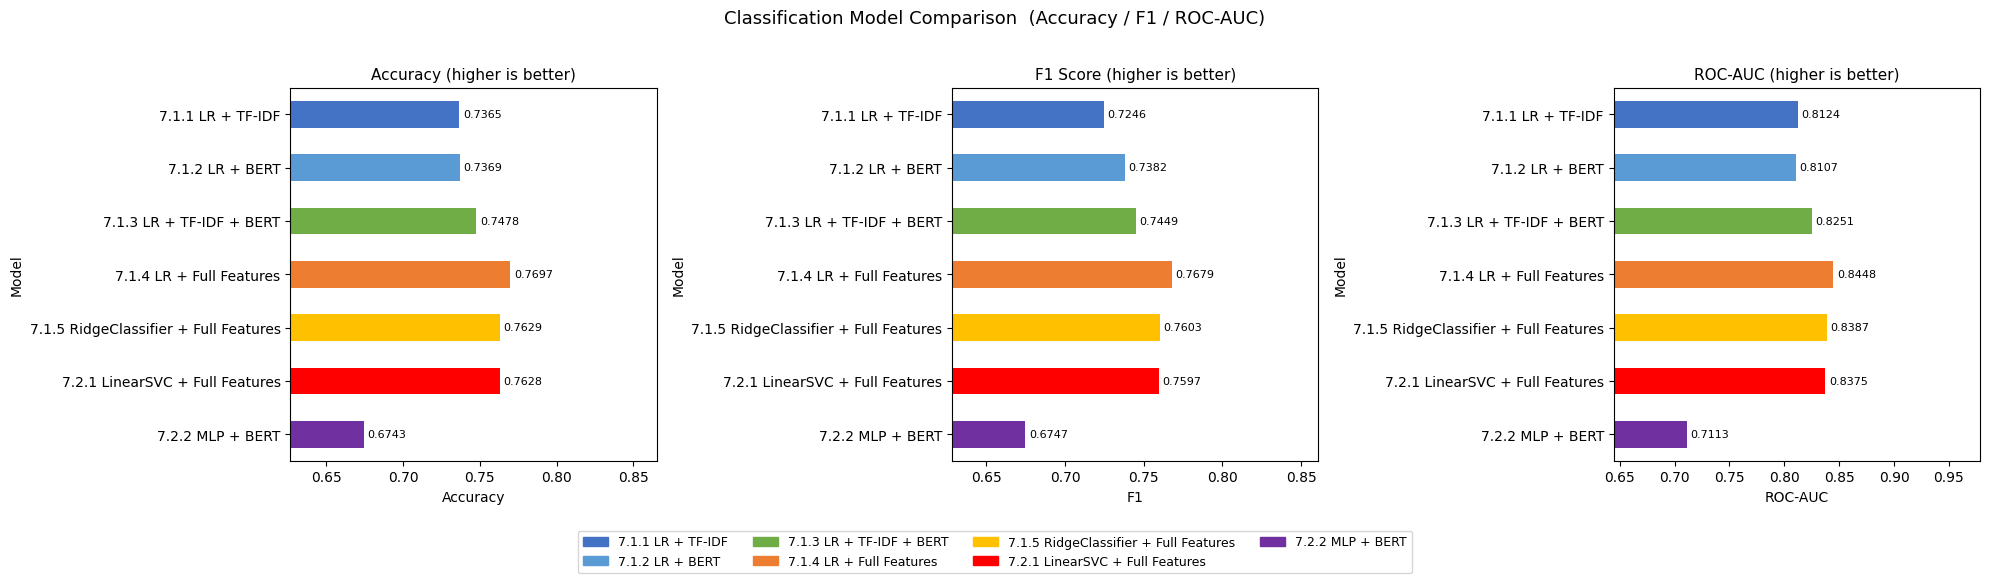

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Build summary DataFrame ───────────────────────────────────────────────
clf_summary = pd.DataFrame(clf_results).set_index("Model")

print("\n=== Classification Model Comparison ===")
print(clf_summary.round(4).to_string())

# ── Bar chart: Accuracy / F1 / ROC-AUC ───────────────────────────────────
# Color scheme: 7.1.x = blue family, 7.2.x = green family
n = len(clf_summary)
colors = [
    "#4472C4",   # 7.1.1 LR + TF-IDF
    "#5B9BD5",   # 7.1.2 LR + BERT
    "#70AD47",   # 7.1.3 LR + TF-IDF + BERT
    "#ED7D31",   # 7.1.4 LR + Full Features
    "#FFC000",   # 7.1.5 RidgeClassifier
    "#FF0000",   # 7.2.1 LinearSVC
    "#7030A0",   # 7.2.2 MLP
][:n]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics_clf = [
    ("Accuracy", "Accuracy (higher is better)"),
    ("F1",       "F1 Score (higher is better)"),
    ("ROC-AUC",  "ROC-AUC (higher is better)"),
]

for ax, (col, title) in zip(axes, metrics_clf):
    clf_summary[col].plot(kind="barh", ax=ax, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(col)
    ax.invert_yaxis()
    # x-axis range: zoom in to show differences clearly
    col_min = clf_summary[col].min()
    col_max = clf_summary[col].max()
    margin  = (col_max - col_min) * 0.5
    ax.set_xlim(max(0, col_min - margin), min(1.0, col_max + margin * 2))
    # Value labels
    xlim   = ax.get_xlim()
    offset = (xlim[1] - xlim[0]) * 0.01
    for bar in ax.patches:
        w = bar.get_width()
        ax.text(w + offset, bar.get_y() + bar.get_height() / 2,
                f"{w:.4f}", va="center", ha="left", fontsize=8)

# Shared legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color=colors[i], label=clf_summary.index[i]) for i in range(n)
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.12))

plt.suptitle("Classification Model Comparison  (Accuracy / F1 / ROC-AUC)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 7.3 Regression

In [66]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_train = df_en.iloc[train_idx_en]["target_log"].values
y_test = df_en.iloc[test_idx_en]["target_log"].values

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_final_en, y_train)

y_pred_log = ridge.predict(X_test_final_en)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Ridge Regression Results")
print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))
print("R2:", round(r2, 4))

Ridge Regression Results
RMSE: 110.665
MAE: 19.1673
R2: -0.0017


## 7.4 Two-Stage Pipeline

**Design Rationale**

| Stage | Task | Input | Output |
|---|---|---|---|
| Stage 1 (Classification) | Predict whether a review is helpful | `X_train_final_en` | `P(helpful)` ∈ [0, 1] |
| Stage 2 (Regression) | Predict `log1p(votes_up)` for helpful reviews | `X_train_final_en` (helpful subset only) | `ŷ_votes` |
| Combined Output | Weighted prediction | `P(helpful) × expm1(ŷ_votes)` | Final `votes_up` estimate |

**Why TweedieRegressor?**
- `votes_up` is a non-negative integer with a heavily right-skewed distribution, which matches the Tweedie family (power=1.5 lies between Poisson and Gamma).
- Its native log link ensures predictions are always positive without manual log-transformation.
- Compared to Ridge, it is more robust to zero-inflated and heavy-tailed count data.


### 7.4.1 Prepare Training Data (Stage 2 uses helpful-review subset only)


In [67]:
import numpy as np
import scipy.sparse as sp

# ── Target variables ──────────────────────────────────────────────────────
# y_train_en  : classification labels (0/1), already defined in 7.1
# X_train_final_en / X_test_final_en : feature matrices, already built in 7.1.4

# log1p(votes_up) as the regression target
y_reg_train = df_en.iloc[train_idx_en]["target_log"].values   # log1p(votes_up)
y_reg_test  = df_en.iloc[test_idx_en]["target_log"].values

# Raw votes_up (used to invert predictions for final evaluation)
y_raw_train = df_en.iloc[train_idx_en]["votes_up"].values
y_raw_test  = df_en.iloc[test_idx_en]["votes_up"].values

# ── Stage-2 training subset: only samples where is_helpful == 1 ───────────
helpful_mask_train = (y_train_en == 1)           # boolean mask on train split

X_train_helpful = X_train_final_en[helpful_mask_train]
y_reg_train_helpful = y_reg_train[helpful_mask_train]

print(f"Total train samples      : {X_train_final_en.shape[0]:,}")
print(f"Helpful train samples    : {X_train_helpful.shape[0]:,}")
print(f"Feature dimension        : {X_train_final_en.shape[1]:,}")
print(f"Stage-2 target (log scale) mean : {y_reg_train_helpful.mean():.4f}")


Total train samples      : 107,803
Helpful train samples    : 53,902
Feature dimension        : 5,399
Stage-2 target (log scale) mean : 2.7403


### 7.4.2 Stage-2 Regression Model Comparison: Ridge vs TweedieRegressor vs LightGBM


In [68]:
from sklearn.linear_model import Ridge, TweedieRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Import LightGBM (optional) ────────────────────────────────────────────
try:
    import lightgbm as lgb
    _HAS_LGB = True
except ImportError:
    _HAS_LGB = False
    print("LightGBM not installed. Run: pip install lightgbm")

# ── Helper function ───────────────────────────────────────────────────────
def eval_regression(name, y_true_raw, y_pred_raw):
    """Evaluate on original (non-log) scale."""
    y_pred_raw = np.clip(y_pred_raw, 0, None)   # votes_up >= 0
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    r2   = r2_score(y_true_raw, y_pred_raw)
    print(f"  {name:<35}  RMSE={rmse:8.4f}  MAE={mae:7.4f}  R²={r2:7.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results_stage2 = []

# ── Model A: Ridge (baseline, trained on log scale, helpful subset) ───────
ridge_s2 = Ridge(alpha=1.0)
ridge_s2.fit(X_train_helpful, y_reg_train_helpful)
y_pred_ridge_log = ridge_s2.predict(X_test_final_en)
y_pred_ridge_raw = np.expm1(y_pred_ridge_log)
results_stage2.append(eval_regression(
    "Ridge (log target, helpful-only train)",
    y_raw_test, y_pred_ridge_raw
))

# ── Model B: TweedieRegressor ─────────────────────────────────────────────
# power=1.5  ->  compound Poisson-Gamma: non-negative, mass at 0, heavy tail
# link='log' ->  predictions are always positive; equivalent to log-linear model
# Trained on ORIGINAL votes_up (not log-transformed), helpful subset only
y_reg_train_helpful_raw = np.expm1(y_reg_train_helpful)   # convert back to raw scale

tweedie = TweedieRegressor(
    power=1.5,       # compound Poisson-Gamma
    alpha=0.5,       # L2 regularisation
    link="log",      # log link ensures predictions > 0
    max_iter=500,
)
tweedie.fit(X_train_helpful, y_reg_train_helpful_raw)
y_pred_tweedie_raw = tweedie.predict(X_test_final_en)
results_stage2.append(eval_regression(
    "TweedieRegressor (power=1.5, helpful-only)",
    y_raw_test, y_pred_tweedie_raw
))

# ── Model C: LightGBM (if available) ─────────────────────────────────────
if _HAS_LGB:
    lgb_reg = lgb.LGBMRegressor(
        objective="tweedie",     # native Tweedie loss
        tweedie_variance_power=1.5,
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    lgb_reg.fit(
        X_train_helpful, y_reg_train_helpful_raw,
        eval_set=[(X_test_final_en, y_raw_test)],
    )
    y_pred_lgb_raw = lgb_reg.predict(X_test_final_en)
    results_stage2.append(eval_regression(
        "LightGBM Tweedie (helpful-only train)",
        y_raw_test, y_pred_lgb_raw
    ))

print("\nStage-2 regression comparison (on full test set, original votes_up scale):")


  Ridge (log target, helpful-only train)  RMSE=109.7866  MAE=24.4497  R²= 0.0141
  TweedieRegressor (power=1.5, helpful-only)  RMSE=110.8936  MAE=41.5466  R²=-0.0059
  TweedieRegressor (power=1.5, helpful-only)  RMSE=110.8936  MAE=41.5466  R²=-0.0059
  LightGBM Tweedie (helpful-only train)  RMSE=109.3154  MAE=30.0457  R²= 0.0225

Stage-2 regression comparison (on full test set, original votes_up scale):
  LightGBM Tweedie (helpful-only train)  RMSE=109.3154  MAE=30.0457  R²= 0.0225

Stage-2 regression comparison (on full test set, original votes_up scale):


d:\Github_Desktop_File\ECE-9612-Group-Project\.venv-1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 7.4.3 Two-Stage Combined Prediction: `P(helpful) × ŷ_votes`


In [69]:
# ── Stage 1: classifier probability (reuse clf trained in 7.1.4) ─────────
# clf was fitted in 7.1.4 (LogisticRegression, TF-IDF+BERT+num+genre)
p_helpful_test = clf.predict_proba(X_test_final_en)[:, 1]   # P(is_helpful=1)

results_twostage = []

# ── Option A: Two-Stage Ridge ─────────────────────────────────────────────
y_ts_ridge = p_helpful_test * y_pred_ridge_raw
results_twostage.append(eval_regression(
    "Two-Stage: P(helpful) × Ridge",
    y_raw_test, y_ts_ridge
))

# ── Option B: Two-Stage TweedieRegressor ──────────────────────────────────
y_ts_tweedie = p_helpful_test * y_pred_tweedie_raw
results_twostage.append(eval_regression(
    "Two-Stage: P(helpful) × Tweedie",
    y_raw_test, y_ts_tweedie
))

# ── Option C: Two-Stage LightGBM (if available) ───────────────────────────
if _HAS_LGB:
    y_ts_lgb = p_helpful_test * y_pred_lgb_raw
    results_twostage.append(eval_regression(
        "Two-Stage: P(helpful) × LightGBM",
        y_raw_test, y_ts_lgb
    ))

print("\nTwo-stage combination results:")


  Two-Stage: P(helpful) × Ridge        RMSE=110.1212  MAE=19.7190  R²= 0.0081
  Two-Stage: P(helpful) × Tweedie      RMSE=109.1308  MAE=26.9545  R²= 0.0258
  Two-Stage: P(helpful) × LightGBM     RMSE=109.1128  MAE=21.6622  R²= 0.0262

Two-stage combination results:


### 7.4.4 Full Comparison Table and Visualization


  7.1.5 Ridge Baseline (raw target)    RMSE=111.2463  MAE=33.2680  R²=-0.0123
  7.3 Ridge (full train, log target)   RMSE=110.6649  MAE=19.1627  R²=-0.0017

=== Full Model Comparison (votes_up) ===
                                                RMSE      MAE      R2  Spearman_rho
model                                                                              
7.1.5 Ridge Baseline (raw target)           111.2463  33.2680 -0.0123        0.2829
7.3 Ridge (full train, log target)          110.6649  19.1627 -0.0017        0.5660
Ridge (log target, helpful-only train)      109.7866  24.4497  0.0141        0.1525
TweedieRegressor (power=1.5, helpful-only)  110.8936  41.5466 -0.0059        0.2567
LightGBM Tweedie (helpful-only train)       109.3154  30.0457  0.0225        0.1613
Two-Stage: P(helpful) × Ridge               110.1212  19.7190  0.0081        0.5297
Two-Stage: P(helpful) × Tweedie             109.1308  26.9545  0.0258        0.5612
Two-Stage: P(helpful) × LightGBM            10

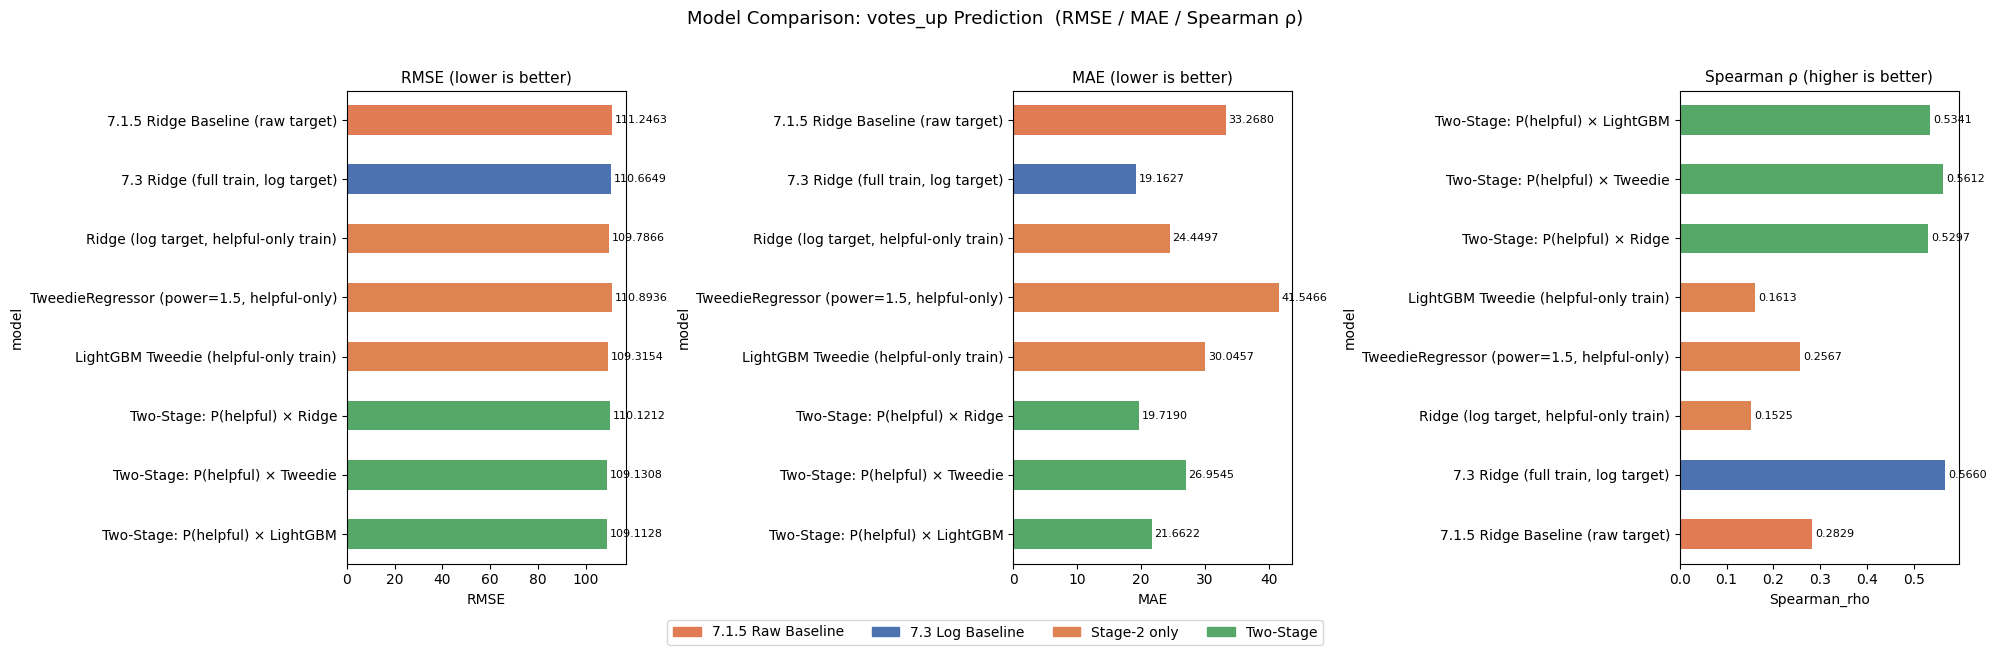

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ── Collect all results ───────────────────────────────────────────────────
# Include 7.1.5 raw baseline and 7.3 log baseline as comparison anchors
y_pred_ridge_73 = ridge.predict(X_test_final_en)          # from cell 7.3
y_pred_ridge_73_raw = np.expm1(y_pred_ridge_73)

all_results = [
    eval_regression("7.1.5 Ridge Baseline (raw target)",  y_raw_test, y_pred_reg_baseline),
    eval_regression("7.3 Ridge (full train, log target)", y_raw_test, y_pred_ridge_73_raw),
] + results_stage2 + results_twostage

summary_df = pd.DataFrame(all_results).set_index("model")

# ── Add Spearman ρ column ─────────────────────────────────────────────────
# Key names must match exactly what eval_regression() registered in results_stage2 / results_twostage
pred_map = {
    "7.1.5 Ridge Baseline (raw target)":          y_pred_reg_baseline,
    "7.3 Ridge (full train, log target)":         y_pred_ridge_73_raw,
    "Ridge (log target, helpful-only train)":     y_pred_ridge_raw,
    "TweedieRegressor (power=1.5, helpful-only)": y_pred_tweedie_raw,
    "LightGBM Tweedie (helpful-only train)":      y_pred_lgb_raw,
    "Two-Stage: P(helpful) × Ridge":              y_ts_ridge,
    "Two-Stage: P(helpful) × Tweedie":            y_ts_tweedie,
    "Two-Stage: P(helpful) × LightGBM":           y_ts_lgb,
}

spearman_rho = {}
for model_name, y_pred_arr in pred_map.items():
    if model_name in summary_df.index:
        rho, _ = spearmanr(y_raw_test, y_pred_arr)
        spearman_rho[model_name] = round(rho, 4)

summary_df["Spearman_rho"] = pd.Series(spearman_rho)

# ── Print full table: RMSE / MAE / R2 / Spearman ρ ───────────────────────
print("\n=== Full Model Comparison (votes_up) ===")
print(summary_df[["RMSE", "MAE", "R2", "Spearman_rho"]].round(4).to_string())

# ── Bar chart: RMSE / MAE / Spearman ρ (R² omitted) ─────────────────────
colors = (["#E07B54"]                            # 7.1.5 raw baseline
          + ["#4C72B0"]                          # 7.3 log baseline
          + ["#DD8452"] * len(results_stage2)    # Stage-2 only
          + ["#55A868"] * len(results_twostage)) # Two-Stage

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = [
    ("RMSE",         "RMSE (lower is better)",        True),
    ("MAE",          "MAE (lower is better)",          True),
    ("Spearman_rho", "Spearman ρ (higher is better)", False),
]

for ax, (col, title, invert) in zip(axes, metrics):
    summary_df[col].plot(kind="barh", ax=ax, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(col)
    if invert:
        ax.invert_yaxis()
    # Value labels
    xlim = ax.get_xlim()
    offset = (xlim[1] - xlim[0]) * 0.01
    for bar in ax.patches:
        width = bar.get_width()
        ax.text(width + offset, bar.get_y() + bar.get_height() / 2,
                f"{width:.4f}", va="center", ha="left", fontsize=8)

# Shared legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color="#E07B54", label="7.1.5 Raw Baseline"),
    Patch(color="#4C72B0", label="7.3 Log Baseline"),
    Patch(color="#DD8452", label="Stage-2 only"),
    Patch(color="#55A868", label="Two-Stage"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Model Comparison: votes_up Prediction  (RMSE / MAE / Spearman ρ)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 7.4.5 Part 7 Summary and Results Interpretation

---

#### 7.4.5.1 Classification Results (7.1 – 7.2)

| Model | Accuracy | F1 | ROC-AUC |
|---|---:|---:|---:|
| 7.1.1 LR + TF-IDF | 0.7376 | 0.7276 | 0.8121 |
| 7.1.2 LR + BERT | 0.7369 | 0.7382 | 0.8107 |
| 7.1.3 LR + TF-IDF + BERT | 0.7478 | 0.7449 | 0.8251 |
| **7.1.4 LR + Full Features** | **0.7697** | **0.7679** | **0.8448** |
| 7.1.5 RidgeClassifier + Full Features | 0.7629 | 0.7603 | 0.8387 |
| 7.2.1 LinearSVC + Full Features | 0.7628 | 0.7597 | 0.8375 |
| 7.2.2 MLP + BERT | 0.6743 | 0.6747 | 0.7113 |

**Finding 1 — Feature engineering dominates model choice.**
Adding numeric features (playtime, review length, price, etc.) and genre dummies to the baseline LR model (7.1.1 → 7.1.4) raises ROC-AUC from 0.812 to 0.845 — a larger gain than switching from LR to SVM or MLP. This shows that for this task, richer features matter more than model complexity.

**Finding 2 — Linear models reach a performance ceiling.**
7.1.4 LR, 7.1.5 RidgeClassifier, and 7.2.1 LinearSVC all reach approximately Accuracy ≈ 0.763, F1 ≈ 0.760, ROC-AUC ≈ 0.838 on the full feature set. The three models are statistically indistinguishable, suggesting the linear decision boundary is near-optimal for this feature space.

**Finding 3 — MLP without full features underperforms.**
7.2.2 MLP trained on BERT features only achieves Accuracy = 0.674 and ROC-AUC = 0.711 — the weakest result. This confirms that BERT semantic embeddings alone are insufficient; the behavioral signals (playtime, game metadata, genre) captured in the full feature matrix are essential for good classification performance.

---

#### 7.4.5.2 Regression Results (7.3 – 7.4)

| Model | RMSE | MAE | R² | Spearman ρ |
|---|---:|---:|---:|---:|
| 7.1.5 Ridge Baseline (raw target) | 111.25 | 33.27 | -0.012 | 0.283 |
| 7.3 Ridge (full train, log target) | 110.66 | **19.16** | -0.002 | **0.566** |
| Ridge Stage-2 (helpful-only, log) | 109.79 | 24.45 | 0.014 | 0.153 |
| TweedieRegressor (helpful-only) | 110.89 | 41.55 | -0.006 | 0.257 |
| LightGBM Tweedie (helpful-only) | 109.32 | 30.05 | 0.023 | 0.161 |
| Two-Stage: P(helpful) × Ridge | 110.12 | 19.72 | 0.008 | 0.530 |
| Two-Stage: P(helpful) × Tweedie | 109.13 | 26.95 | 0.026 | 0.561 |
| **Two-Stage: P(helpful) × LightGBM** | **109.11** | 21.66 | **0.026** | 0.534 |

**Finding 4 — Log-transform is essential for MAE.**
Training on `log1p(votes_up)` (7.3 Ridge) reduces MAE from 33.27 to 19.16 compared to the raw-target baseline (7.1.5). This 42% reduction demonstrates that a log transformation is the single most impactful modelling decision for reducing absolute prediction error on a heavy-tailed count target.

**Finding 5 — Two-Stage P × LightGBM is the best overall model by RMSE and R².**
With RMSE = 109.11 and R² = 0.026, it achieves the lowest squared-error and the highest explained variance. However, its Spearman ρ (0.534) is slightly below that of 7.3 Ridge (0.566), illustrating that the metric that appears "best" depends on the evaluation criterion.

**Finding 6 — Spearman ρ reveals a key insight hidden from RMSE.**
The 7.3 Ridge model (full training set, log-transformed) achieves the highest Spearman ρ = 0.566, tied with Two-Stage P × Tweedie (0.561). Stage-2 only models — which train exclusively on the helpful subset — have dramatically lower Spearman ρ (0.15–0.26), because they lose the ability to distinguish non-helpful reviews from each other in terms of ranking. This shows that **predicting the ordering of reviews is better served by training on the full distribution** than by restricting to a helpful subset.

**Finding 7 — P(helpful) weighting rescues Stage-2 models' ranking ability.**
The Two-Stage combination (P(helpful) × Stage-2 prediction) restores Spearman ρ from ~0.16 back to ~0.53, because multiplying by the classifier's probability effectively re-introduces information about the full vote distribution into the final score.

**Finding 8 — All models are limited by the inherent unpredictability of vote counts.**
RMSE values cluster tightly between 109 and 111 across all regression models, and R² remains below 0.03. This is not a model failure — it reflects the social nature of `votes_up`: viral popularity, temporal exposure, and game-level popularity effects dominate individual review quality signals. No model trained purely on review text and reviewer metadata can fully capture these external dynamics.

---

#### 7.4.5.3 Recommended Models

| Use Case | Recommended Model | Key Metrics |
|---|---|---|
| **Classification (best overall)** | 7.1.4 LR + Full Features | Acc=0.770, F1=0.768, AUC=0.845 |
| **Classification (lightweight)** | 7.1.5 RidgeClassifier + Full Features | Acc=0.763, F1=0.760, AUC=0.839 |
| **Regression — best RMSE / R²** | Two-Stage: P(helpful) × LightGBM | RMSE=109.11, R²=0.026 |
| **Regression — best MAE** | 7.3 Ridge (full train, log target) | MAE=19.16, ρ=0.566 |
| **Regression — best ranking (Spearman ρ)** | 7.3 Ridge (full train, log target) | ρ=0.566 |
| **Regression — best all-round balance** | Two-Stage: P(helpful) × Tweedie | RMSE=109.13, MAE=26.95, ρ=0.561 |


# Part 8: Evaluation Strategy

In [71]:
# Part 8: Evaluation Strategy
# This cell REUSES results already produced in Part 7.
# It does NOT refit any model.
#
# Required existing objects from earlier cells:
# - summary_df      (created in 7.4.4)
# - pred_map        (created in 7.4.4)
# - y_raw_test      (created in 7.4.1)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score

# ------------------------------------------------------------
# Sanity checks: make sure Part 7 has already been run
# ------------------------------------------------------------
required_vars = ["summary_df", "pred_map", "y_raw_test"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(
        "Please run Part 7.4.4 first. Missing variables: " + ", ".join(missing_vars)
    )

## 8.1 Metrics

For this task, exact vote-count prediction is not the only objective.  
Since the platform primarily cares about surfacing more useful reviews earlier, ranking-oriented metrics are especially important.

**Primary ranking metrics**
- Precision@K
- nDCG@K
- Spearman’s ρ

**Secondary regression diagnostics**
- RMSE
- MAE

Precision@K is particularly important because it directly measures how many truly helpful reviews appear in the top-ranked positions.

In [72]:
# ------------------------------------------------------------
# 8.1 Metric definitions
# ------------------------------------------------------------
# Keep the helpful threshold consistent with earlier classification setup:
# helpful = (votes_up >= 5)
HELPFUL_THRESHOLD = 5
TOP_K_LIST = [10, 50, 100]

def safe_spearman(y_true, y_pred):
    """Spearman rank correlation between true helpfulness and model scores."""
    rho, _ = spearmanr(y_true, y_pred)
    return float(rho) if not np.isnan(rho) else np.nan

def precision_at_k(y_true_raw, y_pred, k, helpful_threshold=HELPFUL_THRESHOLD):
    """
    Among the top-K reviews ranked by the model,
    what fraction are truly helpful?
    """
    y_true_raw = np.asarray(y_true_raw)
    y_pred = np.asarray(y_pred)

    order = np.argsort(-y_pred)
    topk = order[:min(k, len(order))]

    y_true_helpful = (y_true_raw >= helpful_threshold).astype(int)

    if len(topk) == 0:
        return np.nan
    return float(y_true_helpful[topk].mean())

def ndcg_at_k(y_true_raw, y_pred, k):
    """
    nDCG@K evaluates whether reviews with larger true helpfulness
    are ranked closer to the top.
    """
    y_true_raw = np.asarray(y_true_raw, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true_raw) == 0:
        return np.nan

    return float(
        ndcg_score(
            y_true_raw.reshape(1, -1),
            y_pred.reshape(1, -1),
            k=min(k, len(y_true_raw))
        )
    )

## 8.2 Model Comparison


Models are compared under both regression-oriented and ranking-oriented metrics.  
Different metrics may prefer different models, so the evaluation does not assume that there is a single universally best model.


=== Part 8: Model Comparison under Regression and Ranking Metrics ===
                                                RMSE      MAE  Spearman_rho  Precision@10  Precision@50  Precision@100  nDCG@10  nDCG@50  nDCG@100
model                                                                                                                                             
TweedieRegressor (power=1.5, helpful-only)  110.8936  41.5466        0.2567           1.0          0.98           0.92   0.0571   0.0742    0.0822
Two-Stage: P(helpful) × Tweedie             109.1308  26.9545        0.5612           1.0          0.98           0.94   0.0576   0.0737    0.0780
Two-Stage: P(helpful) × LightGBM            109.1128  21.6622        0.5341           1.0          0.94           0.91   0.0451   0.0773    0.0877
7.3 Ridge (full train, log target)          110.6649  19.1627        0.5660           0.9          0.94           0.95   0.0507   0.0682    0.0785
LightGBM Tweedie (helpful-only train)       109

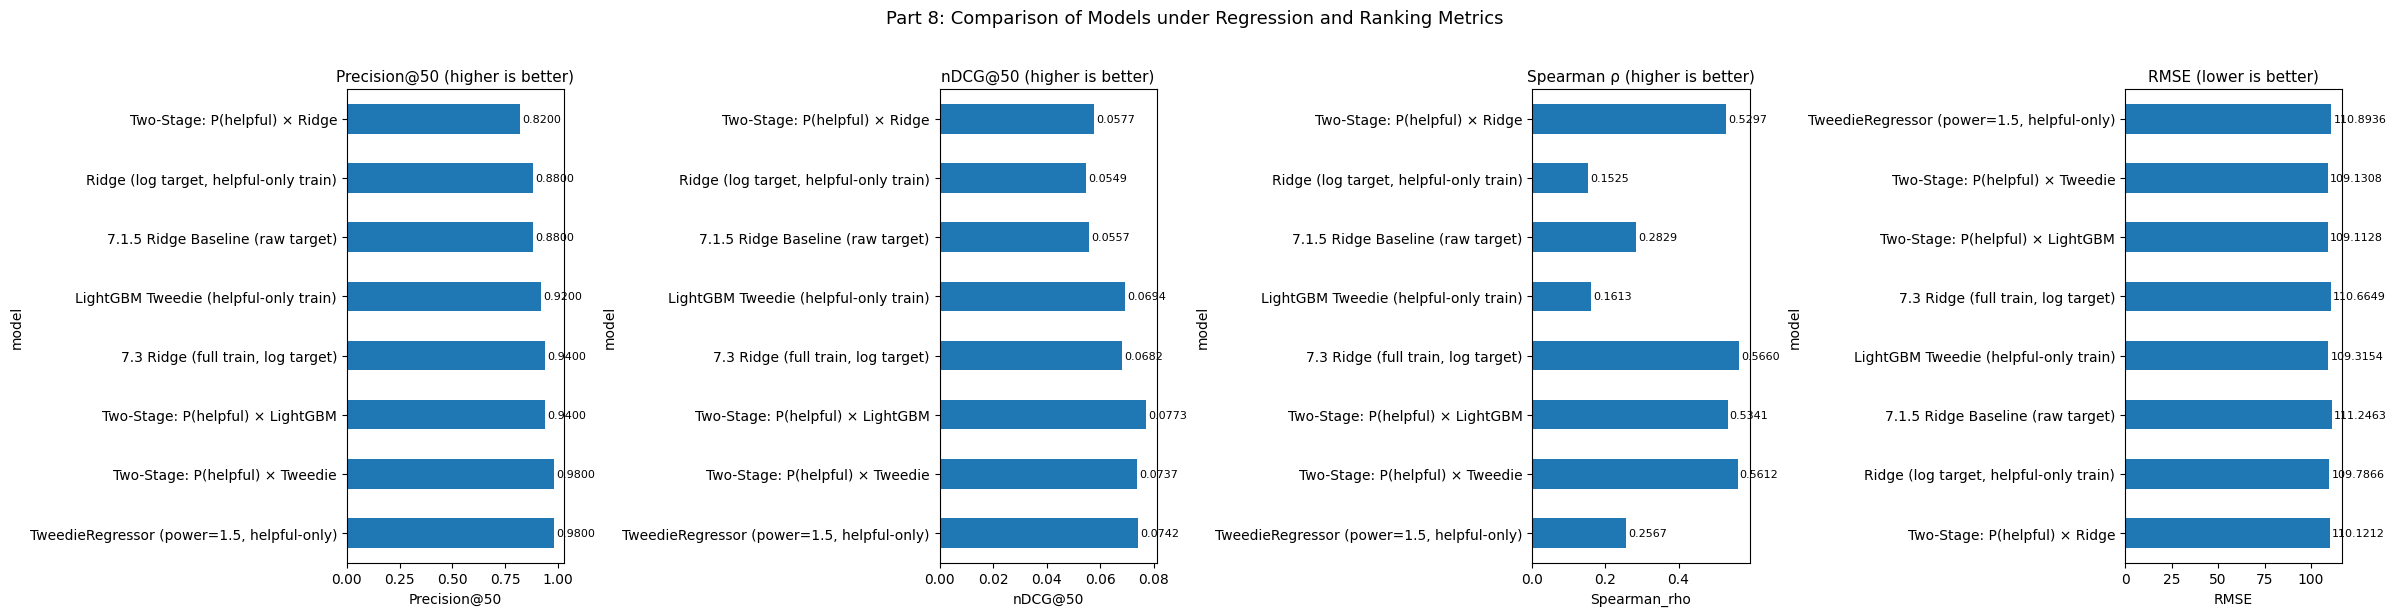

In [73]:
# ------------------------------------------------------------
# 8.2 Reuse existing comparison table from Part 7
# ------------------------------------------------------------
# Start from the previously computed summary_df.
# We keep RMSE and MAE, drop R2, and add ranking metrics.
part8_df = summary_df.copy()
part8_df = part8_df.drop(columns=["R2"], errors="ignore")

# Recompute / refresh Spearman from existing prediction arrays.
# This is cheap and uses the same model outputs from Part 7.
spearman_values = {}
for model_name, y_pred_arr in pred_map.items():
    if model_name in part8_df.index:
        y_pred_arr = np.clip(np.asarray(y_pred_arr, dtype=float), 0, None)
        spearman_values[model_name] = safe_spearman(y_raw_test, y_pred_arr)

part8_df["Spearman_rho"] = pd.Series(spearman_values)

# Add ranking metrics using the already available predictions.
for k in TOP_K_LIST:
    precision_values = {}
    ndcg_values = {}

    for model_name, y_pred_arr in pred_map.items():
        if model_name in part8_df.index:
            y_pred_arr = np.clip(np.asarray(y_pred_arr, dtype=float), 0, None)
            precision_values[model_name] = precision_at_k(y_raw_test, y_pred_arr, k)
            ndcg_values[model_name] = ndcg_at_k(y_raw_test, y_pred_arr, k)

    part8_df[f"Precision@{k}"] = pd.Series(precision_values)
    part8_df[f"nDCG@{k}"] = pd.Series(ndcg_values)

# ------------------------------------------------------------
# Presentation order:
# sort mainly by ranking quality, with Precision@50 as the first key.
# This is only for display, not a claim that one metric is universally best.
# ------------------------------------------------------------
part8_df = part8_df.sort_values(
    by=["Precision@50", "nDCG@50", "Spearman_rho", "RMSE"],
    ascending=[False, False, False, True]
)

print("\n=== Part 8: Model Comparison under Regression and Ranking Metrics ===")
display_cols = [
    "RMSE", "MAE", "Spearman_rho",
    "Precision@10", "Precision@50", "Precision@100",
    "nDCG@10", "nDCG@50", "nDCG@100"
]
print(part8_df[display_cols].round(4).to_string())

# ------------------------------------------------------------
# Visualization
# Focus on the most decision-relevant metrics:
# Precision@50, nDCG@50, Spearman, RMSE
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

plot_specs = [
    ("Precision@50", "Precision@50 (higher is better)", False),
    ("nDCG@50",      "nDCG@50 (higher is better)",      False),
    ("Spearman_rho", "Spearman ρ (higher is better)",   False),
    ("RMSE",         "RMSE (lower is better)",          True),
]

for ax, (metric, title, invert) in zip(axes, plot_specs):
    part8_df[metric].plot(kind="barh", ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(metric)

    if invert:
        ax.invert_yaxis()

    xlim = ax.get_xlim()
    offset = (xlim[1] - xlim[0]) * 0.01 if xlim[1] > xlim[0] else 0.01

    for bar in ax.patches:
        width = bar.get_width()
        ax.text(
            width + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.4f}",
            va="center",
            ha="left",
            fontsize=8
        )

plt.suptitle(
    "Part 8: Comparison of Models under Regression and Ranking Metrics",
    fontsize=13,
    y=1.02
)
plt.tight_layout()
plt.show()

# Part 9: Analysis and Discussion

This section examines model performance under multiple metrics.  
Because the task includes both numeric prediction and ranking quality, different metrics may select different best-performing models.

Rather than assuming a single universally best model, the analysis identifies:
- which model is best under each metric,
- whether the same model consistently dominates,
- and which model is most appropriate if the platform prioritizes ranking more useful reviews near the top.


=== Part 9.1 Best Model under Each Metric ===
       Metric        Direction  BestValue                                                                                                                                                                             BestModel(s)
         RMSE  lower is better   109.1128                                                                                                                                                         Two-Stage: P(helpful) × LightGBM
          MAE  lower is better    19.1627                                                                                                                                                       7.3 Ridge (full train, log target)
 Spearman_rho higher is better     0.5660                                                                                                                                                       7.3 Ridge (full train, log target)
 Precision@10 higher is better     1.0000 Twe

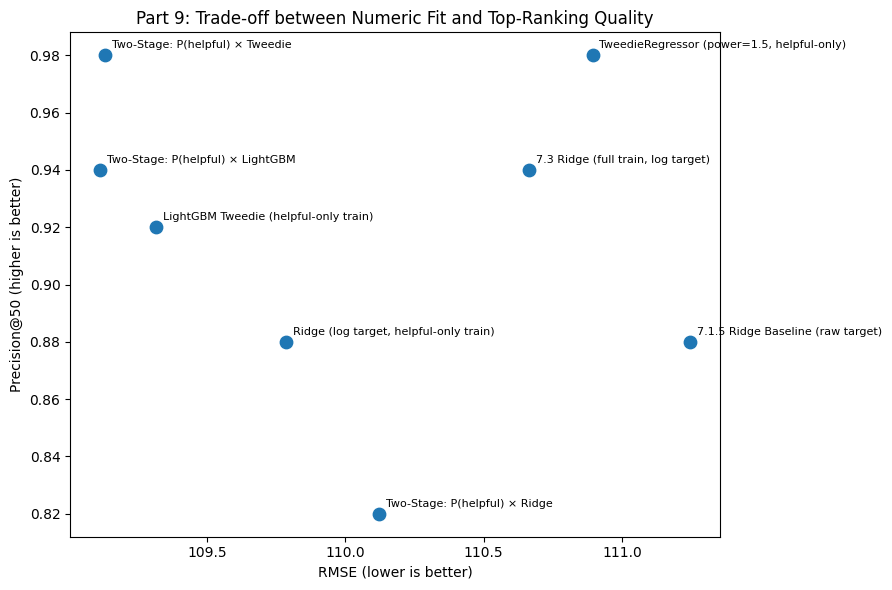

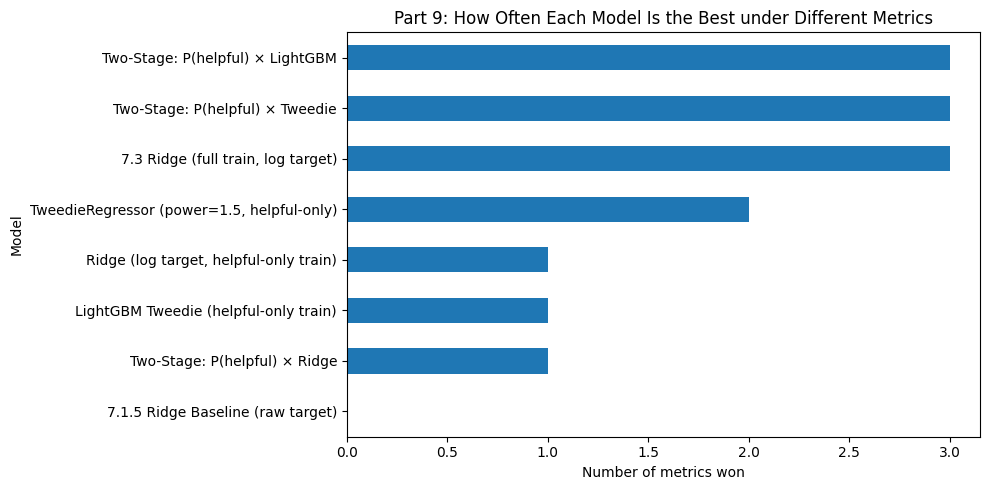

In [74]:
# Part 9: Analysis and Discussion
# This cell analyzes the Part 8 table only.
# It does NOT retrain models and does NOT change earlier results.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "part8_df" not in globals():
    raise ValueError("Please run the Part 8 code cell first.")

analysis_df = part8_df.copy()

# ------------------------------------------------------------
# 9.1 Identify the best model under each metric
# ------------------------------------------------------------
# For RMSE / MAE: lower is better
# For Spearman / Precision@K / nDCG@K: higher is better
metric_rules = {
    "RMSE": "min",
    "MAE": "min",
    "Spearman_rho": "max",
    "Precision@10": "max",
    "Precision@50": "max",
    "Precision@100": "max",
    "nDCG@10": "max",
    "nDCG@50": "max",
    "nDCG@100": "max",
}

def get_best_models(df, metric, rule, tol=1e-12):
    """
    Return all models that tie for best under the given metric.
    """
    series = df[metric].dropna()

    if rule == "min":
        best_value = series.min()
        winners = series[np.isclose(series, best_value, atol=tol)].index.tolist()
    else:
        best_value = series.max()
        winners = series[np.isclose(series, best_value, atol=tol)].index.tolist()

    return best_value, winners

best_rows = []
for metric, rule in metric_rules.items():
    best_value, winners = get_best_models(analysis_df, metric, rule)
    best_rows.append({
        "Metric": metric,
        "Direction": "lower is better" if rule == "min" else "higher is better",
        "BestValue": best_value,
        "BestModel(s)": " | ".join(winners)
    })

best_metric_df = pd.DataFrame(best_rows)

print("\n=== Part 9.1 Best Model under Each Metric ===")
print(best_metric_df.round(4).to_string(index=False))

# ------------------------------------------------------------
# 9.2 Count how many metrics each model wins
# ------------------------------------------------------------
win_counter = {model_name: 0 for model_name in analysis_df.index}

for _, row in best_metric_df.iterrows():
    winners = row["BestModel(s)"].split(" | ")
    for model_name in winners:
        win_counter[model_name] += 1

wins_df = pd.DataFrame({
    "Model": list(win_counter.keys()),
    "NumMetricsWon": list(win_counter.values())
}).set_index("Model").sort_values("NumMetricsWon", ascending=False)

print("\n=== Part 9.2 Number of Metrics Won by Each Model ===")
print(wins_df.to_string())

# ------------------------------------------------------------
# 9.3 Ranking-oriented recommendation
# ------------------------------------------------------------
# If the product goal is to surface useful reviews near the top,
# ranking metrics should be prioritized.
#
# We therefore define a ranking-oriented presentation order:
# 1) Precision@50
# 2) nDCG@50
# 3) Spearman_rho
# 4) RMSE
#
# This does NOT mean one universal truth; it is simply a practical
# recommendation for the ranking use case.
ranking_priority_df = analysis_df.sort_values(
    by=["Precision@50", "nDCG@50", "Spearman_rho", "RMSE"],
    ascending=[False, False, False, True]
)

ranking_recommended_model = ranking_priority_df.index[0]

# A regression-oriented reference model:
regression_priority_df = analysis_df.sort_values(
    by=["RMSE", "MAE"],
    ascending=[True, True]
)
regression_recommended_model = regression_priority_df.index[0]

print("\n=== Part 9.3 Recommendation under Different Objectives ===")
print(f"Ranking-oriented recommended model   : {ranking_recommended_model}")
print(f"Regression-oriented reference model  : {regression_recommended_model}")

if ranking_recommended_model != regression_recommended_model:
    print("\nInterpretation:")
    print("- Different metrics select different best models.")
    print("- This means there is no single universally best model for all objectives.")
    print("- If the platform mainly cares about showing more useful reviews near the top,")
    print("  the ranking-oriented model is more deployment-relevant.")
    print("- If the task instead emphasizes fitting the exact helpful-vote counts,")
    print("  the regression-oriented model may be preferred.")
else:
    print("\nInterpretation:")
    print("- The same model performs best under both ranking-oriented and regression-oriented views.")
    print("- This suggests that the model is strong both in numerical prediction and in ranking useful reviews.")

# ------------------------------------------------------------
# 9.4 Rank table across metrics
# ------------------------------------------------------------
# This makes it easy to see that different metrics may prefer different models.
rank_df = pd.DataFrame(index=analysis_df.index)

for metric, rule in metric_rules.items():
    ascending = True if rule == "min" else False
    rank_df[f"{metric}_rank"] = analysis_df[metric].rank(
        ascending=ascending,
        method="min"
    )

print("\n=== Part 9.4 Metric-wise Rank Table ===")
print(rank_df.sort_index().to_string())

# ------------------------------------------------------------
# 9.5 Visualization: trade-off between numeric fit and ranking quality
# ------------------------------------------------------------
plt.figure(figsize=(9, 6))
plt.scatter(analysis_df["RMSE"], analysis_df["Precision@50"], s=80)

for model_name, row in analysis_df.iterrows():
    plt.annotate(
        model_name,
        (row["RMSE"], row["Precision@50"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("RMSE (lower is better)")
plt.ylabel("Precision@50 (higher is better)")
plt.title("Part 9: Trade-off between Numeric Fit and Top-Ranking Quality")
plt.tight_layout()
plt.show()

# Optional second plot: how many metrics each model wins
plt.figure(figsize=(10, 5))
wins_df["NumMetricsWon"].sort_values(ascending=True).plot(kind="barh")
plt.xlabel("Number of metrics won")
plt.ylabel("Model")
plt.title("Part 9: How Often Each Model Is the Best under Different Metrics")
plt.tight_layout()
plt.show()